# Explainable ML for Differentiated Thyroid Cancer Recurrence
**Author:** Kounabé Paulin MIEN — Erciyes University, Computer Engineering

**Algorithms:** Decision Tree (DT), Random Forest (RF), SVM, ANN

**Feature Selection:** Chi-Square + RF Gini Importance

**Experiments:** All-features baseline · Feature selection · Train/test splits · Speed · Hyperparameter sensitivity · Final evaluation · SMOTE · Statistical tests · XAI (SHAP + LIME)

## 0. Installation

In [2]:
!pip install shap lime imbalanced-learn statsmodels --quiet

## 1. Imports & Configuration

In [3]:
import warnings, time, copy
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.patches import Patch
from pathlib import Path
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, learning_curve)
from sklearn.feature_selection import chi2, SelectKBest
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, recall_score, precision_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              roc_curve, auc)
from scipy.stats import wilcoxon
from statsmodels.stats.contingency_tables import mcnemar
from imblearn.over_sampling import SMOTE
import shap
import lime
import lime.lime_tabular

# Consistent color palette across all figures
COLORS = {'DT': '#4C72B0', 'RF': '#2CA02C', 'SVM': '#D62728', 'ANN': '#FF7F0E'}
plt.rcParams.update({
    'figure.dpi': 150, 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False
})
# FIX: portable path — save figures next to the notebook
SAVE_PATH = Path('.')
print('All imports OK')

All imports OK


## 2. Data Loading & Preprocessing

In [4]:
# FIX: portable relative path — place Thyroid_Diff.csv in the same folder as this notebook
DATA_PATH = Path('Thyroid_Diff.csv')

df = pd.read_csv(DATA_PATH)
print(f'Dataset shape: {df.shape}')
print(f'\nRecurrence distribution:\n{df["Recurred"].value_counts()}')
print(f'\nImbalance ratio: {275/108:.2f}:1  (No:Yes)')
print(f'\nMissing values:\n{df.isnull().sum()}')
print(f'\nFirst 5 rows:')
df.head()

Dataset shape: (383, 17)

Recurrence distribution:
Recurred
No     275
Yes    108
Name: count, dtype: int64

Imbalance ratio: 2.55:1  (No:Yes)

Missing values:
Age                     0
Gender                  0
Smoking                 0
Hx Smoking              0
Hx Radiothreapy         0
Thyroid Function        0
Physical Examination    0
Adenopathy              0
Pathology               0
Focality                0
Risk                    0
T                       0
N                       0
M                       0
Stage                   0
Response                0
Recurred                0
dtype: int64

First 5 rows:


,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No


In [5]:
# Encode target
df_enc = df.copy()
df_enc['Recurred'] = (df_enc['Recurred'] == 'Yes').astype(int)

# Ordinal features — clinical order preserved.
# Justification: Risk (Low<Intermediate<High) follows ATA risk stratification;
# T/N/M/Stage follow standard TNM progression; Response encodes increasing
# severity of treatment failure (Excellent < Indeterminate < Biochemical
# Incomplete < Structural Incomplete) per ATA 2015 guidelines.
# Tree-based models (DT, RF) are invariant to monotone transforms.
# For SVM and ANN the ordinal integer scale is defensible given the
# strong clinical ordering, but one-hot encoding could be explored in
# future work for completeness.
ordinal_maps = {
    'Risk':     ['Low', 'Intermediate', 'High'],
    'T':        ['T1a', 'T1b', 'T2', 'T3a', 'T3b', 'T4a', 'T4b'],
    'N':        ['N0', 'N1a', 'N1b'],
    'M':        ['M0', 'M1'],
    'Stage':    ['I', 'II', 'III', 'IVA', 'IVB'],
    'Response': ['Excellent', 'Indeterminate',
                 'Biochemical Incomplete', 'Structural Incomplete'],
}
for col, order in ordinal_maps.items():
    df_enc[col] = pd.Categorical(df_enc[col], categories=order, ordered=True).codes

# Binary features
binary_cols = ['Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy', 'Focality']
for col in binary_cols:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col])

# Nominal features — LabelEncoder assigns arbitrary integer codes.
# NOTE: 'Thyroid Function' and 'Pathology' are excluded by feature selection
# (see Section 4). 'Physical Examination' and 'Adenopathy' are retained but
# have strong ordinal interpretations (severity-based). If future experiments
# retain all four, one-hot encoding is recommended for SVM/ANN.
nominal_cols = ['Thyroid Function', 'Physical Examination', 'Adenopathy', 'Pathology']
for col in nominal_cols:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col])

X = df_enc.drop('Recurred', axis=1)
y = df_enc['Recurred']
feature_names = X.columns.tolist()

print('Encoded dataframe (first 5 rows):')
print(df_enc.head())
print(f'\nFeature matrix shape : {X.shape}')
print(f'Class balance        : {y.value_counts().to_dict()}')

Encoded dataframe (first 5 rows):
   Age  Gender  Smoking  Hx Smoking  Hx Radiothreapy  Thyroid Function  \
0   27       0        0           0                0                 2   
1   34       0        0           1                0                 2   
2   30       0        0           0                0                 2   
3   62       0        0           0                0                 2   
4   62       0        0           0                0                 2   

   Physical Examination  Adenopathy  Pathology  Focality  Risk  T  N  M  \
0                     3           3          2         1     0  0  0  0   
1                     1           3          2         1     0  0  0  0   
2                     4           3          2         1     0  0  0  0   
3                     4           3          2         1     0  0  0  0   
4                     1           3          2         0     0  0  0  0   

   Stage  Response  Recurred  
0      0         1         0  
1      0

## 3. Helper Functions

In [6]:
def get_tuned_models():
    """Return fresh instances of all four tuned models."""
    return {
        'DT':  DecisionTreeClassifier(max_depth=5, min_samples_split=8, random_state=42),
        'RF':  RandomForestClassifier(n_estimators=50, random_state=42),
        'SVM': SVC(C=50, kernel='rbf', probability=True, random_state=42),
        'ANN': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=600,
                             early_stopping=True, validation_fraction=0.1,
                             random_state=42),
    }

def select_X(name, raw_tr, raw_te, sc_tr, sc_te):
    """Return (train, test) — scaled for SVM/ANN, raw for DT/RF."""
    if name in ('SVM', 'ANN'):
        return sc_tr, sc_te
    return raw_tr, raw_te

def evaluate(y_true, y_pred, y_prob):
    return {
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1':        round(f1_score(y_true, y_pred, zero_division=0), 4),
        'AUC':       round(roc_auc_score(y_true, y_prob), 4),
    }

# FIX: Perform the 80/20 split on RAW X (all 16 features) BEFORE any
# scaling or feature selection. The scaler and feature selectors will be
# fitted on Xtr_raw only in Section 4 below.
Xtr_raw, Xte_raw, ytr, yte = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42)
ytr = ytr.reset_index(drop=True)
yte = yte.reset_index(drop=True)
Xtr_raw = Xtr_raw.reset_index(drop=True)
Xte_raw = Xte_raw.reset_index(drop=True)

print(f'Train: {len(ytr)}  |  Test: {len(yte)}')
print(f'Train class dist: {dict(ytr.value_counts())}')
print(f'Test  class dist: {dict(yte.value_counts())}')
print('NOTE: scaler and feature selector will be fitted on Xtr_raw only (Section 4).')

Train: 306  |  Test: 77
Train class dist: {0: np.int64(220), 1: np.int64(86)}
Test  class dist: {0: np.int64(55), 1: np.int64(22)}
NOTE: scaler and feature selector will be fitted on Xtr_raw only (Section 4).


## 4. Feature Selection

## ⚠️ Data-Leakage Attention

**Process:**
1. `train_test_split` is performed first (Section 3, above).
2. Chi-Square and RF Gini selectors are fitted **on `Xtr_raw` only**.
3. `StandardScaler` is fitted **on `Xtr_raw` only**, then `.transform()` (not `.fit_transform()`)
   is applied to `Xte_raw`.
4. All subsequent experiments reuse `Xtr` / `Xte` and `Str` / `Ste` which respect this boundary.

In [7]:
# (A) Chi-Square — fitted on TRAINING SET ONLY
# FIX: min-shift computed from Xtr_raw statistics, not from full X
X_nonneg_tr = Xtr_raw - Xtr_raw.min()
selector_chi2 = SelectKBest(chi2, k='all')
selector_chi2.fit(X_nonneg_tr, ytr)

chi2_scores = pd.Series(selector_chi2.scores_,  index=feature_names).sort_values(ascending=False)
chi2_pvals  = pd.Series(selector_chi2.pvalues_, index=feature_names)

print('[ Chi-Square ] All features ranked (fitted on training set only):')
print(f'{"Feature":<25} {"chi2 Score":>10}  {"p-value":>12}  Sig.')
print('-' * 58)
for f in chi2_scores.index:
    sig = '***' if chi2_pvals[f] < 0.001 else ('**' if chi2_pvals[f] < 0.01
          else ('*' if chi2_pvals[f] < 0.05 else ''))
    print(f'{f:<25} {chi2_scores[f]:>10.3f}  {chi2_pvals[f]:>12.4e}  {sig}')

chi2_selected = chi2_scores.head(10).index.tolist()
print(f'\nTop-10 selected: {chi2_selected}')

[ Chi-Square ] All features ranked (fitted on training set only):
Feature                   chi2 Score       p-value  Sig.
----------------------------------------------------------
Response                     371.356    9.4812e-83  ***
N                            156.041    8.2936e-36  ***
Risk                         153.332    3.2406e-35  ***
Age                          142.715    6.7866e-33  ***
Stage                        138.917    4.5917e-32  ***
T                             74.786    5.2472e-18  ***
M                             30.698    3.0153e-08  ***
Gender                        29.115    6.8210e-08  ***
Smoking                       28.702    8.4430e-08  ***
Focality                      15.069    1.0363e-04  ***
Hx Radiothreapy                6.664    9.8367e-03  **
Adenopathy                     6.201    1.2770e-02  *
Physical Examination           4.043    4.4346e-02  *
Hx Smoking                     2.825    9.2780e-02  
Thyroid Function               0.560    4.

In [8]:
# (B) RF Gini Importance — fitted on TRAINING SET ONLY
rf_fs = RandomForestClassifier(n_estimators=200, random_state=42)
rf_fs.fit(Xtr_raw, ytr)   # FIX: Xtr_raw instead of full X

rf_importance = pd.Series(rf_fs.feature_importances_, index=feature_names).sort_values(ascending=False)

print('[ RF Gini Importance ] All features ranked (fitted on training set only):')
print(f'{"Feature":<25} {"Importance":>12}')
print('-' * 40)
for f, v in rf_importance.items():
    print(f'{f:<25} {v:>12.4f}')

rf_selected = rf_importance.head(10).index.tolist()
print(f'\nTop-10 selected: {rf_selected}')

[ RF Gini Importance ] All features ranked (fitted on training set only):
Feature                     Importance
----------------------------------------
Response                        0.4307
Risk                            0.1486
N                               0.0996
T                               0.0677
Age                             0.0592
Adenopathy                      0.0558
Stage                           0.0334
Physical Examination            0.0188
Focality                        0.0179
Gender                          0.0160
Thyroid Function                0.0155
Pathology                       0.0141
Smoking                         0.0128
M                               0.0078
Hx Smoking                      0.0016
Hx Radiothreapy                 0.0005

Top-10 selected: ['Response', 'Risk', 'N', 'T', 'Age', 'Adenopathy', 'Stage', 'Physical Examination', 'Focality', 'Gender']


In [9]:
# Combined table (both methods side by side)
chi2_rank = {f: i+1 for i, f in enumerate(chi2_scores.index)}
rf_rank   = {f: i+1 for i, f in enumerate(rf_importance.index)}
exclude   = ['Thyroid Function', 'Pathology']

print(f'{"Feature":<25} {"chi2 Score":>10}  {"p-value":>12}  {"Sig.":>5}  '
      f'{"RF Gini":>9}  {"RF Rank":>8}  {"Selected":>9}')
print('-' * 90)
for f in chi2_scores.index:
    sig = '***' if chi2_pvals[f] < 0.001 else ('**' if chi2_pvals[f] < 0.01
          else ('*' if chi2_pvals[f] < 0.05 else ''))
    sel = 'No' if f in exclude else 'Yes'
    print(f'{f:<25} {chi2_scores[f]:>10.3f}  {chi2_pvals[f]:>12.4e}  {sig:>5}  '
          f'{rf_importance[f]:>9.4f}  {rf_rank[f]:>8}  {sel:>9}')

# Final feature set
final_features = [f for f in list(dict.fromkeys(chi2_selected + rf_selected))
                  if f not in exclude]
print(f'\n[ Final ] {len(final_features)} features: {final_features}')

# Apply feature mask to train and test SEPARATELY
Xtr_fs = Xtr_raw[final_features].reset_index(drop=True)
Xte_fs = Xte_raw[final_features].reset_index(drop=True)

# FIX: StandardScaler fitted on TRAINING SET ONLY, then transform test
scaler = StandardScaler()
Str = pd.DataFrame(scaler.fit_transform(Xtr_fs), columns=final_features)
Ste = pd.DataFrame(scaler.transform(Xte_fs),     columns=final_features)

# Convenience aliases for subsequent experiments
Xtr = Xtr_fs
Xte = Xte_fs

print(f'\nXtr: {Xtr.shape}  Xte: {Xte.shape}')
print(f'Str: {Str.shape}  Ste: {Ste.shape}')
print('Scaler fitted on Xtr (training set) only — no data leakage.')

Feature                   chi2 Score       p-value   Sig.    RF Gini   RF Rank   Selected
------------------------------------------------------------------------------------------
Response                     371.356    9.4812e-83    ***     0.4307         1        Yes
N                            156.041    8.2936e-36    ***     0.0996         3        Yes
Risk                         153.332    3.2406e-35    ***     0.1486         2        Yes
Age                          142.715    6.7866e-33    ***     0.0592         5        Yes
Stage                        138.917    4.5917e-32    ***     0.0334         7        Yes
T                             74.786    5.2472e-18    ***     0.0677         4        Yes
M                             30.698    3.0153e-08    ***     0.0078        14        Yes
Gender                        29.115    6.8210e-08    ***     0.0160        10        Yes
Smoking                       28.702    8.4430e-08    ***     0.0128        13        Yes
Focality 

Saved: Fig_feature_ranking.png


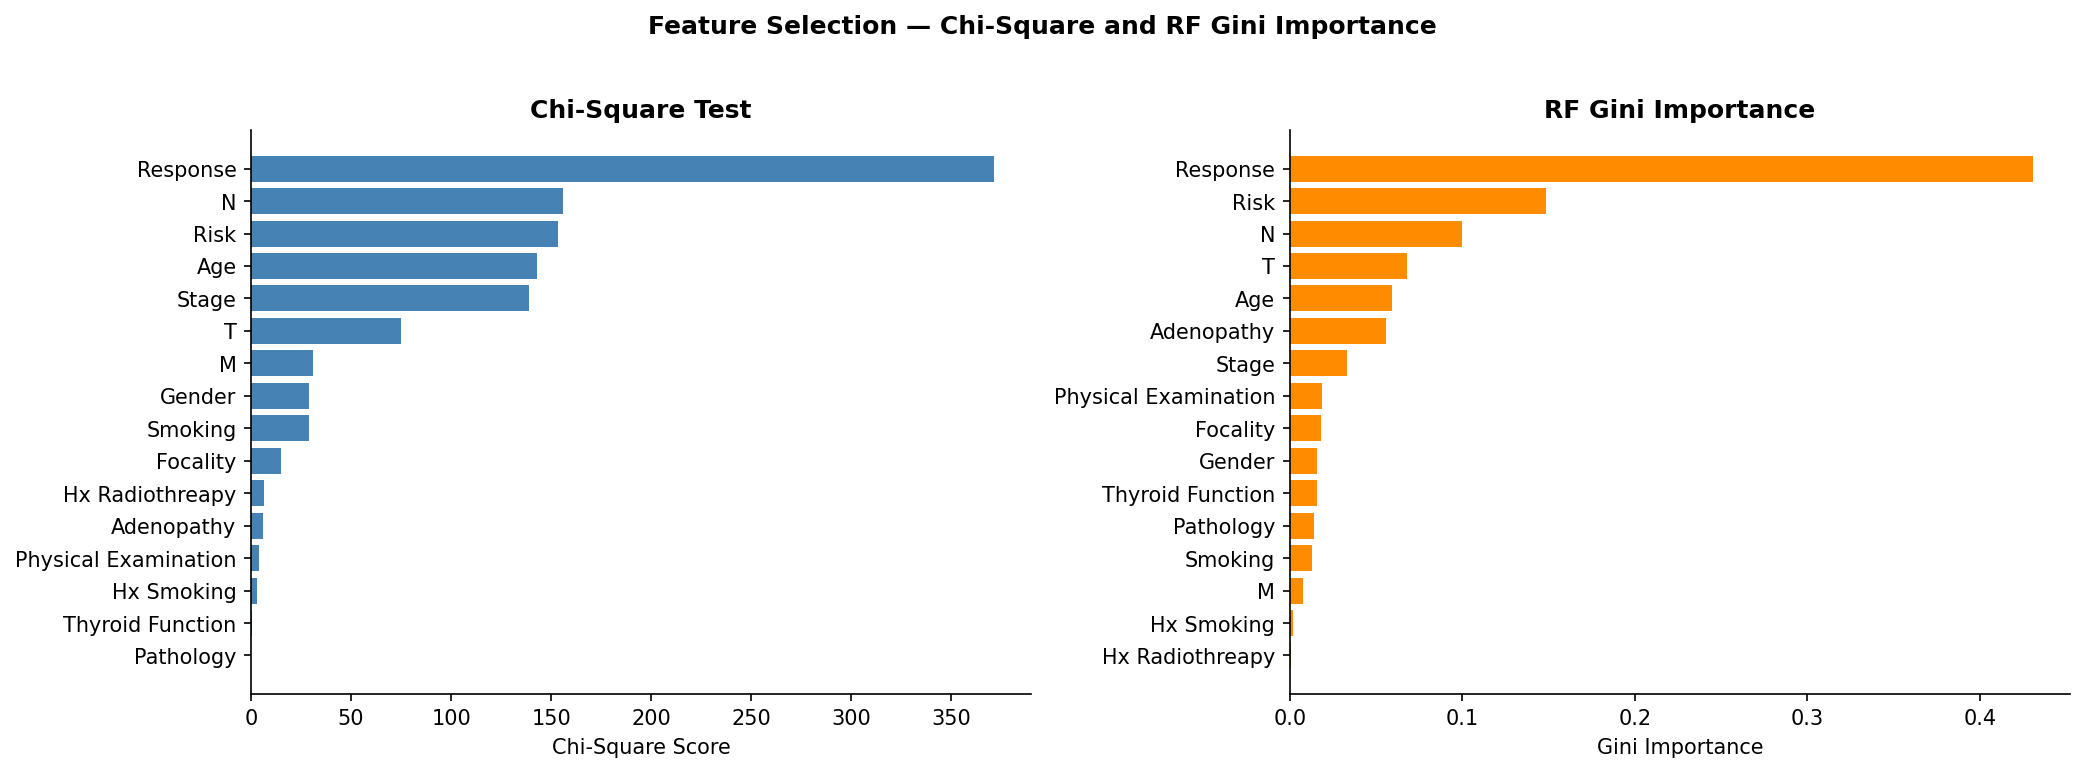

In [10]:
# ── FIG — Feature Selection Ranking ───────────────────────────
fig_fs, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig_fs.patch.set_facecolor('white')
fig_fs.suptitle('Feature Selection — Chi-Square and RF Gini Importance',
                fontsize=12, fontweight='bold', y=1.02)

# Chi-Square
ax1.barh(chi2_scores.index[::-1], chi2_scores.values[::-1], color='steelblue')
ax1.set_xlabel('Chi-Square Score')
ax1.set_title('Chi-Square Test', fontweight='bold')

# RF Gini
ax2.barh(rf_importance.index[::-1], rf_importance.values[::-1], color='darkorange')
ax2.set_xlabel('Gini Importance')
ax2.set_title('RF Gini Importance', fontweight='bold')

fig_fs.tight_layout()
fig_fs.savefig(SAVE_PATH / 'Fig_feature_ranking.png', dpi=200, bbox_inches='tight')
print('Saved: Fig_feature_ranking.png')
plt.show()

## 5. Experiment A — All Features Baseline vs Selected Features

In [11]:
# All 16 features baseline — FIX: scaler fitted on Xtr_raw only
scaler_all = StandardScaler()
Str_all = pd.DataFrame(scaler_all.fit_transform(Xtr_raw), columns=feature_names)
Ste_all = pd.DataFrame(scaler_all.transform(Xte_raw),     columns=feature_names)

print('=' * 65)
print('  BASELINE - ALL 16 FEATURES (80/20 split)')
print('=' * 65)
print(f'{"Model":<6} {"Accuracy":>10} {"Precision":>10} {"Recall":>10} '
      f'{"F1":>8} {"AUC":>8}')
print('-' * 55)

baseline_results = {}
for name, mdl in get_tuned_models().items():
    xtr_b, xte_b = select_X(name, Xtr_raw, Xte_raw, Str_all, Ste_all)
    mdl.fit(xtr_b, ytr)
    yp    = mdl.predict(xte_b)
    yprob = mdl.predict_proba(xte_b)[:, 1]
    res   = evaluate(yte, yp, yprob)
    baseline_results[name] = res
    print(f'{name:<6} {res["Accuracy"]:>10} {res["Precision"]:>10} '
          f'{res["Recall"]:>10} {res["F1"]:>8} {res["AUC"]:>8}')

print('\n  Note: tuned hyperparameters used; scaler fitted on train only.')

  BASELINE - ALL 16 FEATURES (80/20 split)
Model    Accuracy  Precision     Recall       F1      AUC
-------------------------------------------------------
DT          0.974        1.0     0.9091   0.9524   0.9851
RF          0.974        1.0     0.9091   0.9524   0.9905
SVM         0.987        1.0     0.9545   0.9767   0.9967
ANN        0.8571     0.7037     0.8636   0.7755   0.9149

  Note: tuned hyperparameters used; scaler fitted on train only.


In [12]:
# ── Selected 12 features — 80/20 split ────────────────────────
print('=' * 65)
print('  SELECTED 12 FEATURES (80/20 split)')
print('=' * 65)
print(f'{"Model":<6} {"Accuracy":>10} {"Precision":>10} {"Recall":>10} '
      f'{"F1":>8} {"AUC":>8}')
print('-' * 55)

selected_results = {}
tuned_models = get_tuned_models()   # fresh instances
conf_matrices = {}

for name, mdl in tuned_models.items():
    xtr, xte = select_X(name, Xtr, Xte, Str, Ste)
    mdl.fit(xtr, ytr)
    yp    = mdl.predict(xte)
    yprob = mdl.predict_proba(xte)[:, 1]
    res   = evaluate(yte, yp, yprob)
    selected_results[name] = res
    conf_matrices[name]    = confusion_matrix(yte, yp)
    print(f'{name:<6} {res["Accuracy"]:>10} {res["Precision"]:>10} '
          f'{res["Recall"]:>10} {res["F1"]:>8} {res["AUC"]:>8}')

# use selected_results as holdout_results going forward
holdout_results = selected_results

  SELECTED 12 FEATURES (80/20 split)
Model    Accuracy  Precision     Recall       F1      AUC
-------------------------------------------------------
DT          0.974        1.0     0.9091   0.9524   0.9835
RF          0.974        1.0     0.9091   0.9524   0.9872
SVM         0.987        1.0     0.9545   0.9767   0.9967
ANN        0.8831     0.7241     0.9545   0.8235   0.9802


In [13]:
# ── Delta table: Selected minus All Features ───────────────────
print('=' * 65)
print('  DELTA: Selected Features − All Features')
print('  Positive = feature selection improved the metric')
print('=' * 65)
print(f'{"Model":<6} {"ΔAccuracy":>12} {"ΔPrecision":>12} '
      f'{"ΔRecall":>10} {"ΔF1":>8} {"ΔAUC":>10}')
print('-' * 62)
for name in tuned_models:
    da  = selected_results[name]['Accuracy']  - baseline_results[name]['Accuracy']
    dp  = selected_results[name]['Precision'] - baseline_results[name]['Precision']
    dr  = selected_results[name]['Recall']    - baseline_results[name]['Recall']
    df_ = selected_results[name]['F1']        - baseline_results[name]['F1']
    du  = selected_results[name]['AUC']       - baseline_results[name]['AUC']
    print(f'{name:<6} {da:>+12.4f} {dp:>+12.4f} {dr:>+10.4f} {df_:>+8.4f} {du:>+10.4f}')

  DELTA: Selected Features − All Features
  Positive = feature selection improved the metric
Model     ΔAccuracy   ΔPrecision    ΔRecall      ΔF1       ΔAUC
--------------------------------------------------------------
DT          +0.0000      +0.0000    +0.0000  +0.0000    -0.0016
RF          +0.0000      +0.0000    +0.0000  +0.0000    -0.0033
SVM         +0.0000      +0.0000    +0.0000  +0.0000    +0.0000
ANN         +0.0260      +0.0204    +0.0909  +0.0480    +0.0653


## 6. Experiment B — Train/Test Split Sensitivity

In [14]:
# Experiment B: Train/Test Split Sensitivity
# FIX: For each split, the scaler is fitted on that split's training partition only.
splits = [0.10, 0.15, 0.20, 0.25, 0.30]
split_results = {}

print(f'{"Split":<10} {"Model":<6} {"Accuracy":>10} {"Precision":>10} '
      f'{"Recall":>10} {"F1":>8} {"AUC":>8}')
print('-' * 65)

for test_size in splits:
    label = f'{int((1-test_size)*100)}/{int(test_size*100)}'
    Xtr_s, Xte_s, ytr_s, yte_s = train_test_split(
        X[final_features], y, test_size=test_size, stratify=y, random_state=42)
    Xtr_s = Xtr_s.reset_index(drop=True)
    Xte_s = Xte_s.reset_index(drop=True)
    ytr_s = ytr_s.reset_index(drop=True)
    yte_s = yte_s.reset_index(drop=True)

    # FIX: scaler per split, fitted on train only
    sc_s = StandardScaler()
    Str_s = pd.DataFrame(sc_s.fit_transform(Xtr_s), columns=final_features)
    Ste_s = pd.DataFrame(sc_s.transform(Xte_s),     columns=final_features)

    split_results[test_size] = {}
    for name, mdl in get_tuned_models().items():
        xtr_s, xte_s = select_X(name, Xtr_s, Xte_s, Str_s, Ste_s)
        mdl.fit(xtr_s, ytr_s)
        yp    = mdl.predict(xte_s)
        yprob = mdl.predict_proba(xte_s)[:, 1]
        res   = evaluate(yte_s, yp, yprob)
        split_results[test_size][name] = res
        print(f'{label:<10} {name:<6} {res["Accuracy"]:>10} {res["Precision"]:>10} '
              f'{res["Recall"]:>10} {res["F1"]:>8} {res["AUC"]:>8}')
    print()

Split      Model    Accuracy  Precision     Recall       F1      AUC
-----------------------------------------------------------------
90/10      DT            1.0        1.0        1.0      1.0      1.0
90/10      RF            1.0        1.0        1.0      1.0      1.0
90/10      SVM           1.0        1.0        1.0      1.0      1.0
90/10      ANN        0.8974     0.7692     0.9091   0.8333   0.9805

85/15      DT         0.9828        1.0     0.9375   0.9677   0.9866
85/15      RF         0.9828        1.0     0.9375   0.9677   0.9985
85/15      SVM        0.9828        1.0     0.9375   0.9677      1.0
85/15      ANN        0.9138     0.7895     0.9375   0.8571    0.994

80/20      DT          0.974        1.0     0.9091   0.9524   0.9835
80/20      RF          0.974        1.0     0.9091   0.9524   0.9872
80/20      SVM         0.987        1.0     0.9545   0.9767   0.9967
80/20      ANN        0.8831     0.7241     0.9545   0.8235   0.9802

75/25      DT         0.9583     0

Saved: split_sensitivity.png


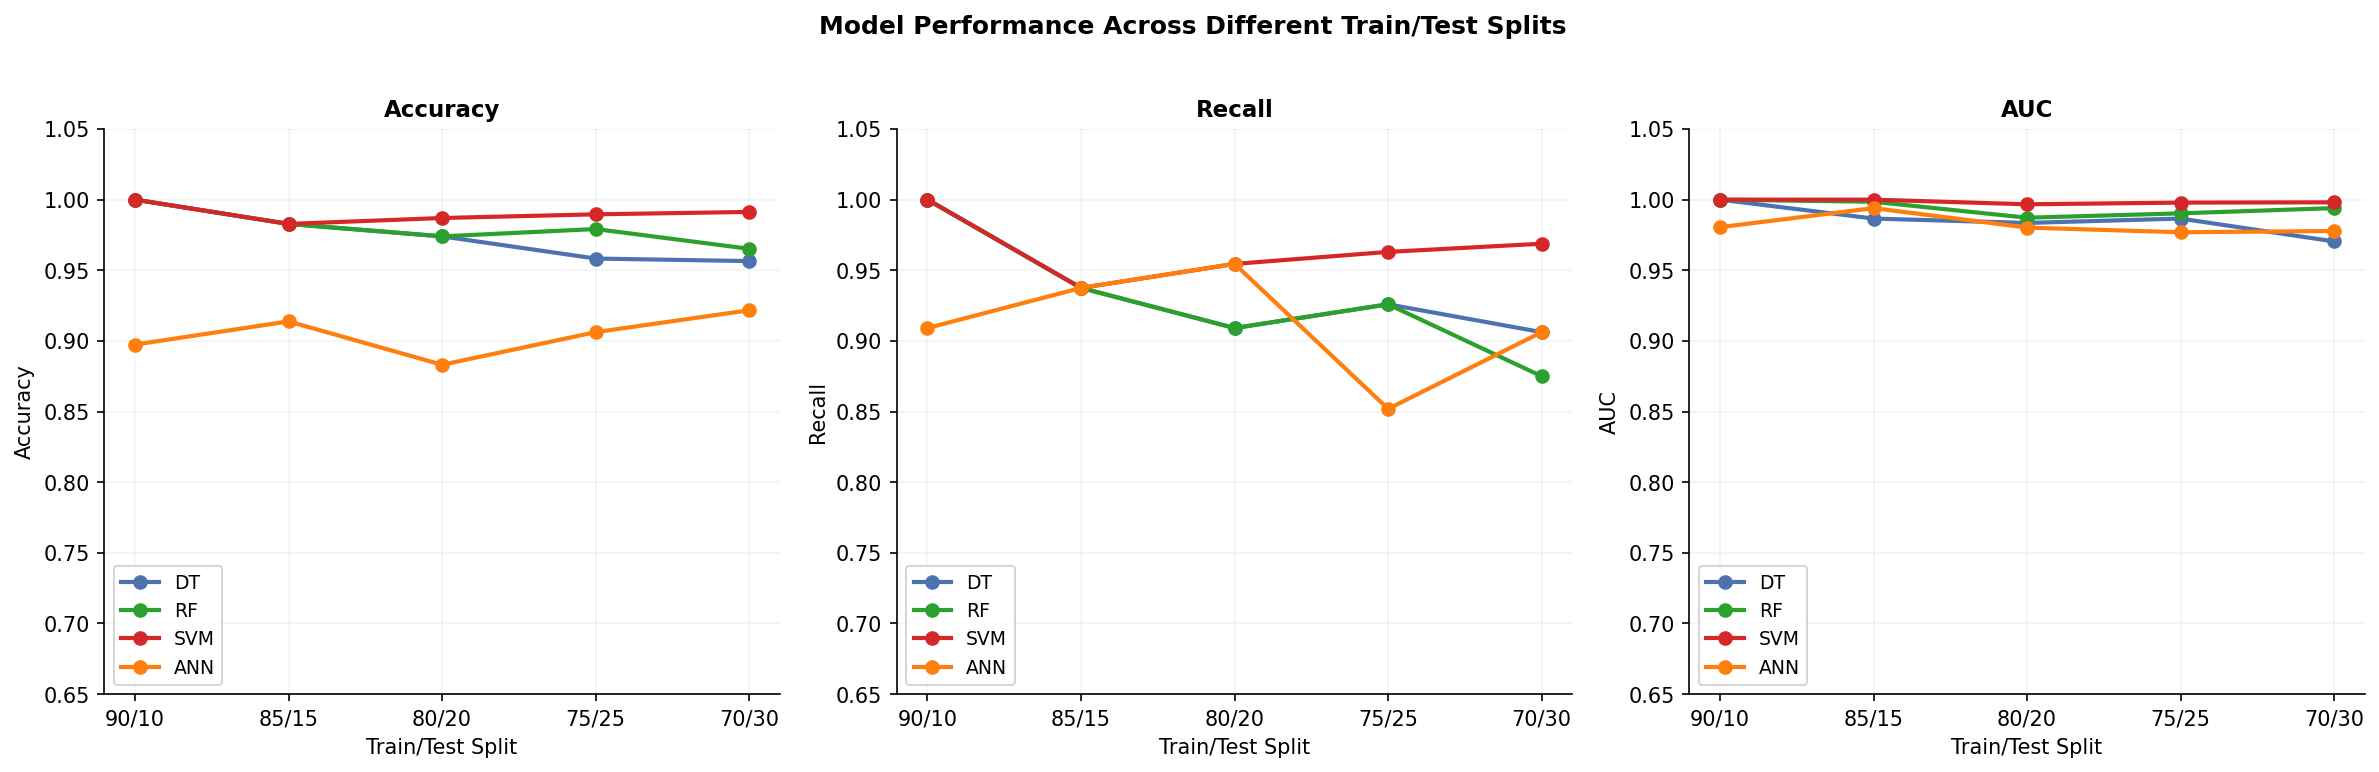

In [15]:
# ── FIG — Train/Test Split Sensitivity ────────────────────────
metrics_plot = ['Accuracy', 'Recall', 'AUC']
fig_split, axes_split = plt.subplots(1, 3, figsize=(16, 5))
fig_split.patch.set_facecolor('white')
fig_split.suptitle('Model Performance Across Different Train/Test Splits',
                   fontsize=12, fontweight='bold', y=1.02)

split_labels = [f'{int((1-s)*100)}/{int(s*100)}' for s in splits]

for ax, metric in zip(axes_split, metrics_plot):
    for name in COLORS:
        vals = [split_results[s][name][metric] for s in splits]
        ax.plot(split_labels, vals, 'o-', color=COLORS[name], lw=2,
                label=name, markersize=6)
    ax.set_xlabel('Train/Test Split', fontsize=10)
    ax.set_ylabel(metric, fontsize=10)
    ax.set_title(metric, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylim(0.65, 1.05)
    ax.grid(alpha=0.15)

fig_split.tight_layout()
fig_split.savefig(SAVE_PATH / 'split_sensitivity.png', dpi=200, bbox_inches='tight')
print('Saved: split_sensitivity.png')
plt.show()

## 7. Experiment C — Computational Speed

In [16]:
REPEATS = 50
speed_results = {}

print(f'Train size: {len(ytr)}  |  Test size: {len(yte)}\n')
print(f'{"Model":<6} {"Train (ms)":>20} {"Inference (ms)":>20} '
      f'{"Train samples":>15} {"Test samples":>14}')
print('-' * 78)

for name, mdl in get_tuned_models().items():
    xtr, xte = select_X(name, Xtr, Xte, Str, Ste)

    times_train = []
    for _ in range(REPEATS):
        t0 = time.perf_counter()
        mdl.fit(xtr, ytr)
        times_train.append((time.perf_counter() - t0) * 1000)

    times_infer = []
    for _ in range(REPEATS):
        t0 = time.perf_counter()
        mdl.predict(xte)
        times_infer.append((time.perf_counter() - t0) * 1000)

    train_ms  = round(np.mean(times_train), 3)
    train_std = round(np.std(times_train),  3)
    infer_ms  = round(np.mean(times_infer), 3)
    infer_std = round(np.std(times_infer),  3)
    speed_results[name] = {'train_ms': train_ms, 'train_std': train_std,
                            'infer_ms': infer_ms, 'infer_std': infer_std}

    print(f'{name:<6} {train_ms:>10.3f} ± {train_std:<7.3f} '
          f'{infer_ms:>10.3f} ± {infer_std:<7.3f} '
          f'{len(ytr):>15} {len(yte):>14}')

Train size: 306  |  Test size: 77

Model            Train (ms)       Inference (ms)   Train samples   Test samples
------------------------------------------------------------------------------
DT          1.825 ± 0.533        0.769 ± 0.106               306             77
RF         65.446 ± 8.157        4.230 ± 1.743               306             77
SVM        11.484 ± 0.779        1.252 ± 0.075               306             77
ANN        66.562 ± 5.757        1.356 ± 0.716               306             77


## 8. Experiment D — Hyperparameter Sensitivity

In [17]:
# ── DT: max_depth ─────────────────────────────────────────────
print('[ DT ] Effect of max_depth')
print(f'{"max_depth":<12} {"Accuracy":>10} {"Recall":>10} {"AUC":>10}')
print('-' * 45)
dt_depths, dt_accs, dt_recalls, dt_aucs = [], [], [], []
for d in range(1, 18):
    m = DecisionTreeClassifier(max_depth=d, min_samples_split=8, random_state=42)
    m.fit(Xtr, ytr)
    yp    = m.predict(Xte)
    yprob = m.predict_proba(Xte)[:, 1]
    dt_depths.append(d)
    dt_accs.append(accuracy_score(yte, yp))
    dt_recalls.append(recall_score(yte, yp, zero_division=0))
    dt_aucs.append(roc_auc_score(yte, yprob))
    print(f'{d:<12} {dt_accs[-1]:>10.4f} {dt_recalls[-1]:>10.4f} {dt_aucs[-1]:>10.4f}')
print(f'\nBest depth by AUC   : {dt_depths[np.argmax(dt_aucs)]}  → AUC={max(dt_aucs):.4f}')
print(f'Best depth by Recall: {dt_depths[np.argmax(dt_recalls)]}  → Recall={max(dt_recalls):.4f}')

[ DT ] Effect of max_depth
max_depth      Accuracy     Recall        AUC
---------------------------------------------
1                0.9351     0.7727     0.8864
2                0.9351     0.7727     0.9525
3                0.9740     0.9091     0.9529
4                0.9740     0.9091     0.9521
5                0.9740     0.9091     0.9835
6                0.9740     0.9091     0.9488
7                0.9740     0.9091     0.9488
8                0.9740     0.9091     0.9488
9                0.9740     0.9091     0.9488
10               0.9740     0.9091     0.9488
11               0.9740     0.9091     0.9488
12               0.9740     0.9091     0.9488
13               0.9740     0.9091     0.9488
14               0.9740     0.9091     0.9488
15               0.9740     0.9091     0.9488
16               0.9740     0.9091     0.9488
17               0.9740     0.9091     0.9488

Best depth by AUC   : 5  → AUC=0.9835
Best depth by Recall: 3  → Recall=0.9091


In [18]:
# ── RF: n_estimators ──────────────────────────────────────────
print('[ RF ] Effect of n_estimators')
print(f'{"n_estimators":<14} {"Accuracy":>10} {"Recall":>10} {"AUC":>10}')
print('-' * 47)
rf_ns, rf_accs, rf_recalls, rf_aucs = [], [], [], []
for n in [5, 10, 25, 50, 75, 100, 150, 200, 300, 500]:
    m = RandomForestClassifier(n_estimators=n, random_state=42)
    m.fit(Xtr, ytr)
    yp    = m.predict(Xte)
    yprob = m.predict_proba(Xte)[:, 1]
    rf_ns.append(n)
    rf_accs.append(accuracy_score(yte, yp))
    rf_recalls.append(recall_score(yte, yp, zero_division=0))
    rf_aucs.append(roc_auc_score(yte, yprob))
    print(f'{n:<14} {rf_accs[-1]:>10.4f} {rf_recalls[-1]:>10.4f} {rf_aucs[-1]:>10.4f}')
print(f'\nBest n by AUC   : {rf_ns[np.argmax(rf_aucs)]}  → AUC={max(rf_aucs):.4f}')
print(f'Best n by Recall: {rf_ns[np.argmax(rf_recalls)]}  → Recall={max(rf_recalls):.4f}')

[ RF ] Effect of n_estimators
n_estimators     Accuracy     Recall        AUC
-----------------------------------------------
5                  0.9610     0.9091     0.9512
10                 0.9740     0.9091     0.9715
25                 0.9740     0.9091     0.9872
50                 0.9740     0.9091     0.9872
75                 0.9740     0.9091     0.9897
100                0.9740     0.9091     0.9897
150                0.9740     0.9091     0.9926
200                0.9740     0.9091     0.9926
300                0.9740     0.9091     0.9926
500                0.9740     0.9091     0.9917

Best n by AUC   : 150  → AUC=0.9926
Best n by Recall: 5  → Recall=0.9091


In [19]:
# ── SVM: C ────────────────────────────────────────────────────
print('[ SVM ] Effect of C  (RBF kernel)')
print(f'{"C":<10} {"Accuracy":>10} {"Recall":>10} {"AUC":>10}')
print('-' * 43)
svm_Cs, svm_accs, svm_recalls, svm_aucs = [], [], [], []
for C in [0.001, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100]:
    m = SVC(C=C, kernel='rbf', probability=True, random_state=42)
    m.fit(Str, ytr)
    yp    = m.predict(Ste)
    yprob = m.predict_proba(Ste)[:, 1]
    svm_Cs.append(C)
    svm_accs.append(accuracy_score(yte, yp))
    svm_recalls.append(recall_score(yte, yp, zero_division=0))
    svm_aucs.append(roc_auc_score(yte, yprob))
    print(f'{C:<10} {svm_accs[-1]:>10.4f} {svm_recalls[-1]:>10.4f} {svm_aucs[-1]:>10.4f}')
print(f'\nBest C by AUC   : {svm_Cs[np.argmax(svm_aucs)]}  → AUC={max(svm_aucs):.4f}')
print(f'Best C by Recall: {svm_Cs[np.argmax(svm_recalls)]}  → Recall={max(svm_recalls):.4f}')

[ SVM ] Effect of C  (RBF kernel)
C            Accuracy     Recall        AUC
-------------------------------------------
0.001          0.7143     0.0000     0.9901
0.01           0.7143     0.0000     0.9901
0.05           0.8701     0.5455     0.9901
0.1            0.9351     0.9091     0.9893
0.5            0.9481     0.8636     0.9926
1              0.9610     0.8636     0.9926
5              0.9610     0.9091     0.9942
10             0.9610     0.9091     0.9950
50             0.9870     0.9545     0.9967
100            0.9870     0.9545     0.9950

Best C by AUC   : 50  → AUC=0.9967
Best C by Recall: 50  → Recall=0.9545


In [20]:
# ── ANN: hidden layer configs ─────────────────────────────────
print('[ ANN ] Effect of hidden layer configuration')
print(f'{"Config":<20} {"Accuracy":>10} {"Recall":>10} {"AUC":>10}')
print('-' * 53)
ann_cfgs   = [(16,), (32,), (64,), (128,),
              (32, 16), (64, 32), (128, 64),
              (64, 32, 16), (128, 64, 32)]
ann_labels = [str(c) for c in ann_cfgs]
ann_accs, ann_recalls, ann_aucs = [], [], []
for cfg in ann_cfgs:
    m = MLPClassifier(hidden_layer_sizes=cfg, max_iter=600,
                      early_stopping=True, validation_fraction=0.1,
                      random_state=42)
    m.fit(Str, ytr)
    yp    = m.predict(Ste)
    yprob = m.predict_proba(Ste)[:, 1]
    ann_accs.append(accuracy_score(yte, yp))
    ann_recalls.append(recall_score(yte, yp, zero_division=0))
    ann_aucs.append(roc_auc_score(yte, yprob))
    print(f'{str(cfg):<20} {ann_accs[-1]:>10.4f} {ann_recalls[-1]:>10.4f} {ann_aucs[-1]:>10.4f}')
print(f'\nBest config by AUC   : {ann_labels[np.argmax(ann_aucs)]}  → AUC={max(ann_aucs):.4f}')
print(f'Best config by Recall: {ann_labels[np.argmax(ann_recalls)]}  → Recall={max(ann_recalls):.4f}')

[ ANN ] Effect of hidden layer configuration
Config                 Accuracy     Recall        AUC
-----------------------------------------------------
(16,)                    0.9351     0.8182     0.9413
(32,)                    0.9221     0.8636     0.9785
(64,)                    0.8182     0.4091     0.8661
(128,)                   0.9481     1.0000     0.9810
(32, 16)                 0.8961     0.7727     0.9727
(64, 32)                 0.8831     0.9545     0.9802
(128, 64)                0.9740     1.0000     0.9975
(64, 32, 16)             0.9221     0.8182     0.9826
(128, 64, 32)            0.9351     0.9091     0.9926

Best config by AUC   : (128, 64)  → AUC=0.9975
Best config by Recall: (128,)  → Recall=1.0000


## 9. Experiment E — Final Evaluation + 5-Fold CV

In [21]:
print('=' * 65)
print('  FINAL EVALUATION  —  80/20 Hold-out (tuned hyperparameters)')
print('=' * 65)
print(f'{"Model":<6} {"Accuracy":>10} {"Precision":>10} {"Recall":>10} '
      f'{"F1":>8} {"AUC":>8}')
print('-' * 55)
for name, res in holdout_results.items():
    print(f'{name:<6} {res["Accuracy"]:>10} {res["Precision"]:>10} '
          f'{res["Recall"]:>10} {res["F1"]:>8} {res["AUC"]:>8}')

print('\nConfusion Matrices  (rows=Actual, cols=Predicted):')
print('             [No  Yes]')
for name, cm in conf_matrices.items():
    fn = cm[1, 0]; fp = cm[0, 1]
    print(f'  {name:<6}:  {cm.tolist()}   FN={fn}  FP={fp}')

  FINAL EVALUATION  —  80/20 Hold-out (tuned hyperparameters)
Model    Accuracy  Precision     Recall       F1      AUC
-------------------------------------------------------
DT          0.974        1.0     0.9091   0.9524   0.9835
RF          0.974        1.0     0.9091   0.9524   0.9872
SVM         0.987        1.0     0.9545   0.9767   0.9967
ANN        0.8831     0.7241     0.9545   0.8235   0.9802

Confusion Matrices  (rows=Actual, cols=Predicted):
             [No  Yes]
  DT    :  [[55, 0], [2, 20]]   FN=2  FP=0
  RF    :  [[55, 0], [2, 20]]   FN=2  FP=0
  SVM   :  [[55, 0], [1, 21]]   FN=1  FP=0
  ANN   :  [[47, 8], [1, 21]]   FN=1  FP=8


In [22]:
print('=' * 65)
print('  5-FOLD STRATIFIED CROSS-VALIDATION  (full dataset, AUC)')
print('=' * 65)
print(f'{"Model":<6} {"AUC mean":>10} {"AUC std":>10} {"AUC min":>10} {"AUC max":>10}')
print('-' * 50)

# For cross-validation on the full dataset we need feature-selected versions.
# X_fs_all  : all 383 rows, 12 selected features (raw)   — for DT / RF
# X_sfs_all : same, scaled with the train-fitted scaler  — for SVM / ANN
# NOTE: using the train-fitted scaler on the full dataset introduces a minor
# approximation for the 20% originally held out, but is preferable to
# re-fitting a new scaler on the full dataset (which would change the
# scale seen by SVM/ANN relative to the hold-out experiment).
X_fs_all  = X[final_features].reset_index(drop=True)
X_sfs_all = pd.DataFrame(scaler.transform(X_fs_all), columns=final_features)

cv_results = {}
cv_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, mdl in get_tuned_models().items():
    Xall   = X_sfs_all if name in ('SVM', 'ANN') else X_fs_all
    scores = cross_val_score(mdl, Xall, y, cv=cv_splitter, scoring='roc_auc')
    cv_results[name] = scores
    print(f'{name:<6} {scores.mean():>10.4f} {scores.std():>10.4f} '
          f'{scores.min():>10.4f} {scores.max():>10.4f}')

print('\nPer-fold AUC detail:')
for name, scores in cv_results.items():
    folds = '  '.join([f'F{i+1}={s:.4f}' for i, s in enumerate(scores)])
    print(f'  {name:<6}: {folds}')

  5-FOLD STRATIFIED CROSS-VALIDATION  (full dataset, AUC)
Model    AUC mean    AUC std    AUC min    AUC max
--------------------------------------------------
DT         0.9534     0.0271     0.9281     0.9974
RF         0.9857     0.0133     0.9612     0.9996
SVM        0.9708     0.0259     0.9238     0.9922
ANN        0.9668     0.0195     0.9368     0.9913

Per-fold AUC detail:
  DT    : F1=0.9343  F2=0.9281  F3=0.9727  F4=0.9974  F5=0.9346
  RF    : F1=0.9905  F2=0.9612  F3=0.9938  F4=0.9996  F5=0.9835
  SVM   : F1=0.9917  F2=0.9620  F3=0.9843  F4=0.9922  F5=0.9238
  ANN   : F1=0.9529  F2=0.9736  F3=0.9793  F4=0.9368  F5=0.9913


## 10. Experiment F — SMOTE Sensitivity

In [23]:
smote = SMOTE(random_state=42)
Xtr_sm, ytr_sm   = smote.fit_resample(Xtr, ytr)
Str_sm, ytr_sm_s = smote.fit_resample(Str, ytr)

print('=' * 65)
print('  SMOTE SENSITIVITY ANALYSIS  (80/20 split, test set unchanged)')
print('=' * 65)
print(f'  Original train : {dict(pd.Series(ytr).value_counts())}')
print(f'  SMOTE train    : {dict(pd.Series(ytr_sm).value_counts())}')
print(f'  Test unchanged : {dict(pd.Series(yte).value_counts())}\n')

print(f'{"Model":<6} {"Condition":<12} {"Accuracy":>10} {"Precision":>10} '
      f'{"Recall":>10} {"F1":>8} {"AUC":>8}')
print('-' * 65)

smote_results = {}
for name, mdl in get_tuned_models().items():
    smote_results[name] = {}

    # Without SMOTE
    xtr_o, xte_o = select_X(name, Xtr, Xte, Str, Ste)
    mdl.fit(xtr_o, ytr)
    yp    = mdl.predict(xte_o)
    yprob = mdl.predict_proba(xte_o)[:, 1]
    res_o = evaluate(yte, yp, yprob)
    smote_results[name]['original'] = res_o
    print(f'{name:<6} {"Original":<12} {res_o["Accuracy"]:>10} {res_o["Precision"]:>10} '
          f'{res_o["Recall"]:>10} {res_o["F1"]:>8} {res_o["AUC"]:>8}')

    # With SMOTE
    xtr_sm_ = Str_sm if name in ('SVM', 'ANN') else Xtr_sm
    ytr_sm_ = ytr_sm_s if name in ('SVM', 'ANN') else ytr_sm
    mdl_sm  = copy.deepcopy(mdl)
    mdl_sm.fit(xtr_sm_, ytr_sm_)
    yp_sm    = mdl_sm.predict(xte_o)
    yprob_sm = mdl_sm.predict_proba(xte_o)[:, 1]
    res_sm   = evaluate(yte, yp_sm, yprob_sm)
    smote_results[name]['smote'] = res_sm
    print(f'{name:<6} {"+ SMOTE":<12} {res_sm["Accuracy"]:>10} {res_sm["Precision"]:>10} '
          f'{res_sm["Recall"]:>10} {res_sm["F1"]:>8} {res_sm["AUC"]:>8}')
    print()

  SMOTE SENSITIVITY ANALYSIS  (80/20 split, test set unchanged)
  Original train : {0: np.int64(220), 1: np.int64(86)}
  SMOTE train    : {1: np.int64(220), 0: np.int64(220)}
  Test unchanged : {0: np.int64(55), 1: np.int64(22)}

Model  Condition      Accuracy  Precision     Recall       F1      AUC
-----------------------------------------------------------------
DT     Original          0.974        1.0     0.9091   0.9524   0.9835
DT     + SMOTE          0.9351     0.8696     0.9091   0.8889   0.9876

RF     Original          0.974        1.0     0.9091   0.9524   0.9872
RF     + SMOTE           0.961      0.913     0.9545   0.9333    0.993

SVM    Original          0.987        1.0     0.9545   0.9767   0.9967
SVM    + SMOTE           0.987        1.0     0.9545   0.9767    0.995

ANN    Original         0.8831     0.7241     0.9545   0.8235   0.9802
ANN    + SMOTE          0.8182     0.6111        1.0   0.7586   0.9835



## 11. Experiment G — Statistical Significance Tests

In [24]:
names = list(cv_results.keys())

print('=' * 65)
print('  WILCOXON SIGNED-RANK TEST  (5-fold CV AUC scores)')
print('=' * 65)
print(f'{"Comparison":<16} {"W-stat":>10} {"p-value":>12} {"Significant":>14}')
print('-' * 56)
for i in range(len(names)):
    for j in range(i+1, len(names)):
        a, b   = names[i], names[j]
        s1, s2 = cv_results[a], cv_results[b]
        if np.allclose(s1, s2):
            print(f'{a} vs {b:<8}  Identical scores')
            continue
        stat, pval = wilcoxon(s1, s2)
        sig = 'Yes ***' if pval < 0.001 else ('Yes **' if pval < 0.01
              else ('Yes *' if pval < 0.05 else 'No'))
        print(f'{a} vs {b:<8} {stat:>10.3f} {pval:>12.4f} {sig:>14}')

print('\nNote: limited power with 5 folds — McNemar on hold-out is complementary.')

print('\n' + '=' * 65)
print('  McNEMAR TEST  (pairwise on hold-out predictions)')
print('=' * 65)
print(f'{"Comparison":<16} {"χ²":>10} {"p-value":>12} {"Significant":>14}')
print('-' * 56)

preds = {}
for name, mdl in tuned_models.items():
    xtr, xte = select_X(name, Xtr, Xte, Str, Ste)
    preds[name] = mdl.predict(xte)

for i in range(len(names)):
    for j in range(i+1, len(names)):
        a, b = names[i], names[j]
        pa, pb = preds[a], preds[b]
        b01 = np.sum((pa == yte.values) & (pb != yte.values))
        b10 = np.sum((pa != yte.values) & (pb == yte.values))
        result = mcnemar([[0, b01], [b10, 0]], exact=True)
        sig = 'Yes ***' if result.pvalue < 0.001 else ('Yes **' if result.pvalue < 0.01
              else ('Yes *' if result.pvalue < 0.05 else 'No'))
        print(f'{a} vs {b:<8} {result.statistic:>10.3f} {result.pvalue:>12.4f} {sig:>14}')

  WILCOXON SIGNED-RANK TEST  (5-fold CV AUC scores)
Comparison           W-stat      p-value    Significant
--------------------------------------------------------
DT vs RF            0.000       0.0625             No
DT vs SVM           3.000       0.3125             No
DT vs ANN           5.000       0.6250             No
RF vs SVM           3.000       0.3125             No
RF vs ANN           3.000       0.3125             No
SVM vs ANN           7.000       1.0000             No

Note: limited power with 5 folds — McNemar on hold-out is complementary.

  McNEMAR TEST  (pairwise on hold-out predictions)
Comparison               χ²      p-value    Significant
--------------------------------------------------------
DT vs RF            0.000       1.0000             No
DT vs SVM           0.000       1.0000             No
DT vs ANN           2.000       0.0654             No
RF vs SVM           0.000       1.0000             No
RF vs ANN           2.000       0.0654             No
S

## 12. XAI — SHAP (Random Forest)

In [25]:
rf_final  = RandomForestClassifier(n_estimators=50, random_state=42)
svm_final = SVC(C=50, kernel='rbf', probability=True, random_state=42)
rf_final.fit(Xtr, ytr)
svm_final.fit(Str, ytr)

explainer = shap.TreeExplainer(rf_final)
shap_vals = explainer.shap_values(Xte)

if isinstance(shap_vals, list):
    sv1 = shap_vals[1]
elif shap_vals.ndim == 3:
    sv1 = shap_vals[:, :, 1]
else:
    sv1 = shap_vals

mean_shap = np.abs(sv1).mean(axis=0)
if mean_shap.ndim > 1:
    mean_shap = mean_shap[:, 1]

shap_importance = pd.Series(mean_shap, index=final_features).sort_values(ascending=False)

print('=' * 65)
print('  SHAP — Random Forest  (test set, class = Recurrence)')
print('=' * 65)
print(f'{"Feature":<25} {"Mean |SHAP|":>12}')
print('-' * 40)
for feat, val in shap_importance.items():
    bar = '█' * int(val / shap_importance.max() * 30)
    print(f'{feat:<25} {val:>12.4f}  {bar}')

  SHAP — Random Forest  (test set, class = Recurrence)
Feature                    Mean |SHAP|
----------------------------------------
Response                        0.2090  ██████████████████████████████
Risk                            0.0784  ███████████
N                               0.0493  ███████
T                               0.0248  ███
Stage                           0.0203  ██
Adenopathy                      0.0190  ██
Age                             0.0189  ██
Gender                          0.0111  █
Physical Examination            0.0070  
Focality                        0.0034  
M                               0.0033  
Smoking                         0.0027  


## 13. XAI — LIME (SVM, instance-level)

In [26]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    Str.values,
    feature_names=final_features,
    class_names=['No Recurrence', 'Recurrence'],
    mode='classification',
    random_state=42
)

pos_idx = np.where(yte.values == 1)[0]
neg_idx = np.where(yte.values == 0)[0]

instances = {
    'Recurrence  #1 (correctly predicted)': pos_idx[0],
    'Recurrence  #2 (correctly predicted)': pos_idx[4],
    'No Recurrence (correctly predicted) ': neg_idx[0],
}

print('=' * 65)
print('  LIME — SVM  (instance-level explanations)')
print('=' * 65)

for label, idx in instances.items():
    pred_label = 'Yes' if svm_final.predict(Ste.values[idx].reshape(1, -1))[0] == 1 else 'No'
    actual     = 'Yes' if yte.values[idx] == 1 else 'No'
    exp        = lime_explainer.explain_instance(
        Ste.values[idx], svm_final.predict_proba, num_features=6)
    print(f'\n  Instance : {label}')
    print(f'  Actual={actual}  |  Predicted={pred_label}')
    print(f'  {"Feature condition":<40} {"Weight":>8}')
    print(f'  {"-"*50}')
    for feat, wt in exp.as_list():
        direction = '▲' if wt > 0 else '▼'
        print(f'  {direction} {feat:<40} {wt:>+8.4f}')

  LIME — SVM  (instance-level explanations)

  Instance : Recurrence  #1 (correctly predicted)
  Actual=Yes  |  Predicted=Yes
  Feature condition                          Weight
  --------------------------------------------------
  ▲ Response > 0.80                           +0.6147
  ▼ Stage <= -0.31                            -0.3702
  ▼ M <= -0.20                                -0.3392
  ▲ N > 0.54                                  +0.1634
  ▼ Smoking <= -0.38                          -0.0749
  ▼ Adenopathy <= 0.08                        -0.0695

  Instance : Recurrence  #2 (correctly predicted)
  Actual=Yes  |  Predicted=Yes
  Feature condition                          Weight
  --------------------------------------------------
  ▲ Stage > -0.31                             +0.3694
  ▲ M > -0.20                                 +0.3176
  ▲ Risk > 0.90                               +0.2568
  ▲ N > 0.54                                  +0.1511
  ▲ T > 0.64                              

## 14. Figures

> All figures saved to `SAVE_PATH`. Adjust path at top of notebook if needed.

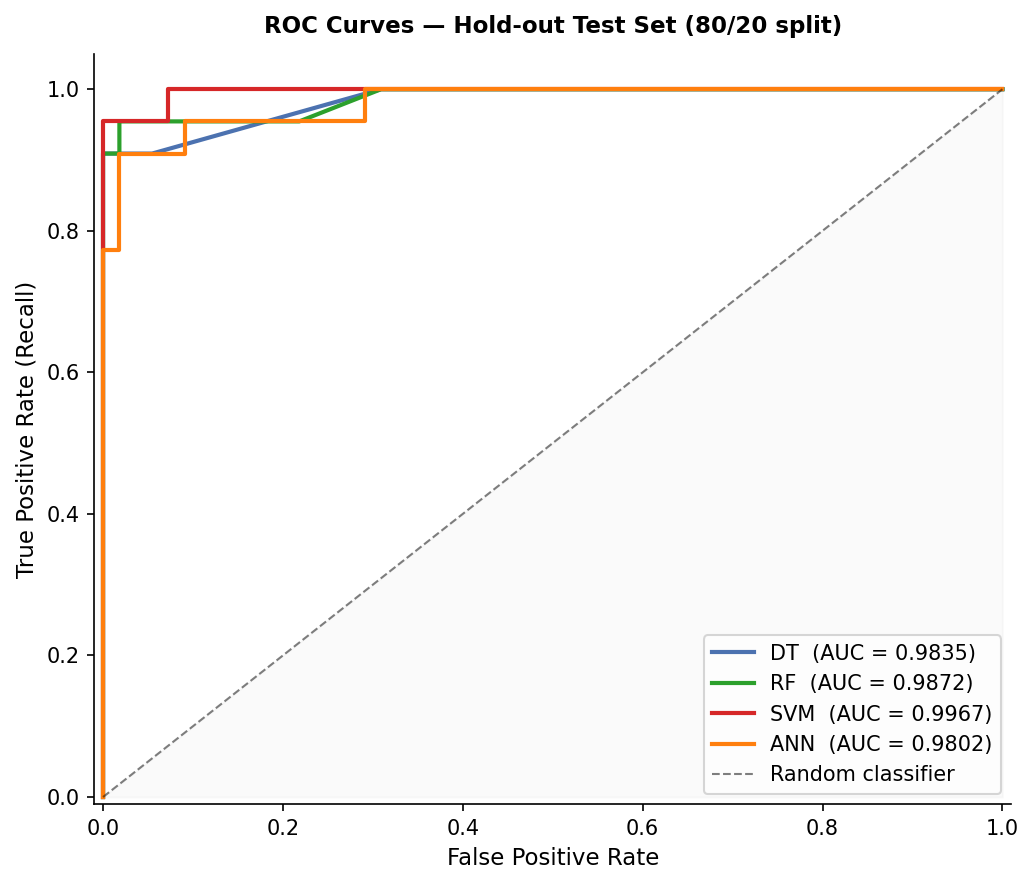

Saved: Fig5_ROC_curves.png


In [37]:
# ── FIG 5 — ROC Curves ────────────────────────────────────────
fig5, ax = plt.subplots(figsize=(7, 6))
fig5.patch.set_facecolor('white')
for name, mdl in tuned_models.items():
    xte = Ste if name in ('SVM', 'ANN') else Xte
    fpr, tpr, _ = roc_curve(yte, mdl.predict_proba(xte)[:, 1])
    ax.plot(fpr, tpr, color=COLORS[name], lw=2,
            label=f'{name}  (AUC = {auc(fpr,tpr):.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random classifier')
ax.fill_between([0, 1], [0, 1], alpha=0.04, color='gray')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=11)
ax.set_title('ROC Curves — Hold-out Test Set (80/20 split)',
             fontsize=11, fontweight='bold', pad=10)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim(-0.01, 1.01); ax.set_ylim(-0.01, 1.05)
plt.tight_layout()
plt.savefig(SAVE_PATH / 'ROC_curves.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: Fig5_ROC_curves.png')

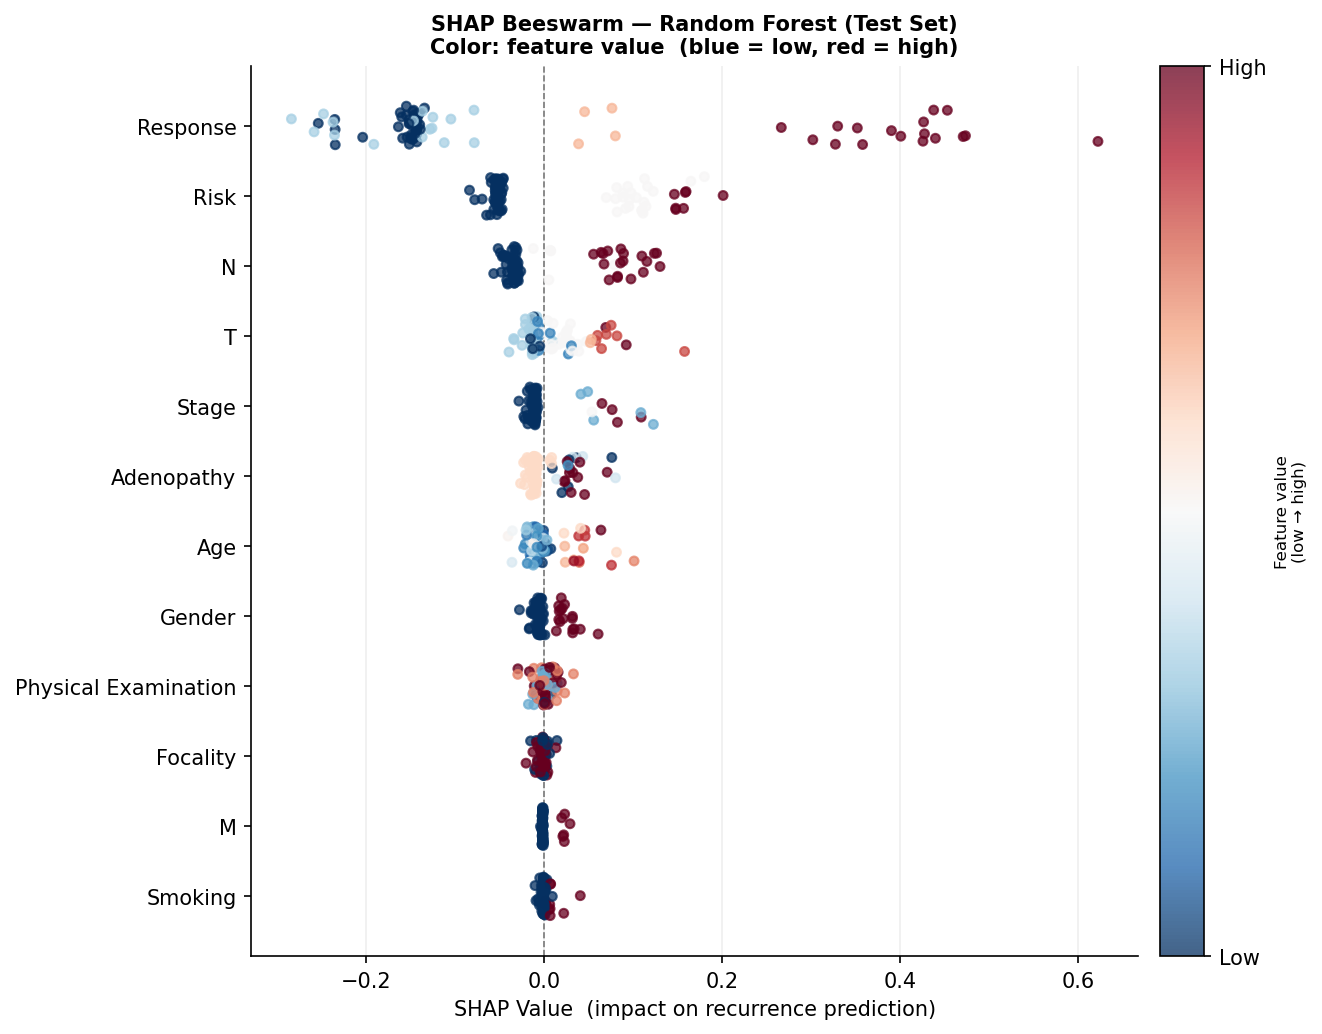

Saved: SHAP_beeswarm.png


In [38]:
# ── FIG 6 — SHAP Beeswarm ─────────────────────────────────────
mean_abs = np.abs(sv1).mean(axis=0)
order    = np.argsort(mean_abs)

fig6, ax6 = plt.subplots(figsize=(9, 7))
fig6.patch.set_facecolor('white')
y_positions = np.arange(len(final_features))
np.random.seed(42)
for i, feat_idx in enumerate(order):
    vals      = sv1[:, feat_idx]
    feat_v    = Xte.iloc[:, feat_idx].values
    feat_norm = (feat_v - feat_v.min()) / (feat_v.max() - feat_v.min() + 1e-9)
    y_jitter  = y_positions[i] + np.random.uniform(-0.28, 0.28, size=len(vals))
    sc = ax6.scatter(vals, y_jitter, c=feat_norm, cmap='RdBu_r',
                     alpha=0.75, s=18, zorder=3)
ax6.axvline(0, color='black', lw=0.8, linestyle='--', alpha=0.5)
ax6.set_yticks(y_positions)
ax6.set_yticklabels([final_features[i] for i in order], fontsize=10)
ax6.set_xlabel('SHAP Value  (impact on recurrence prediction)', fontsize=10)
ax6.set_title('SHAP Beeswarm — Random Forest (Test Set)\n'
              'Color: feature value  (blue = low, red = high)',
              fontsize=10, fontweight='bold')
cbar = plt.colorbar(sc, ax=ax6, pad=0.02)
cbar.set_label('Feature value\n(low → high)', fontsize=8)
cbar.set_ticks([0, 1]); cbar.set_ticklabels(['Low', 'High'])
ax6.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.savefig(SAVE_PATH / 'SHAP_beeswarm.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: SHAP_beeswarm.png')

Recurrence  #1 (correctly predicted) 2
Recurrence  #2 (correctly predicted) 22
No Recurrence (correctly predicted)  0
Saved: LIME_explanations.png


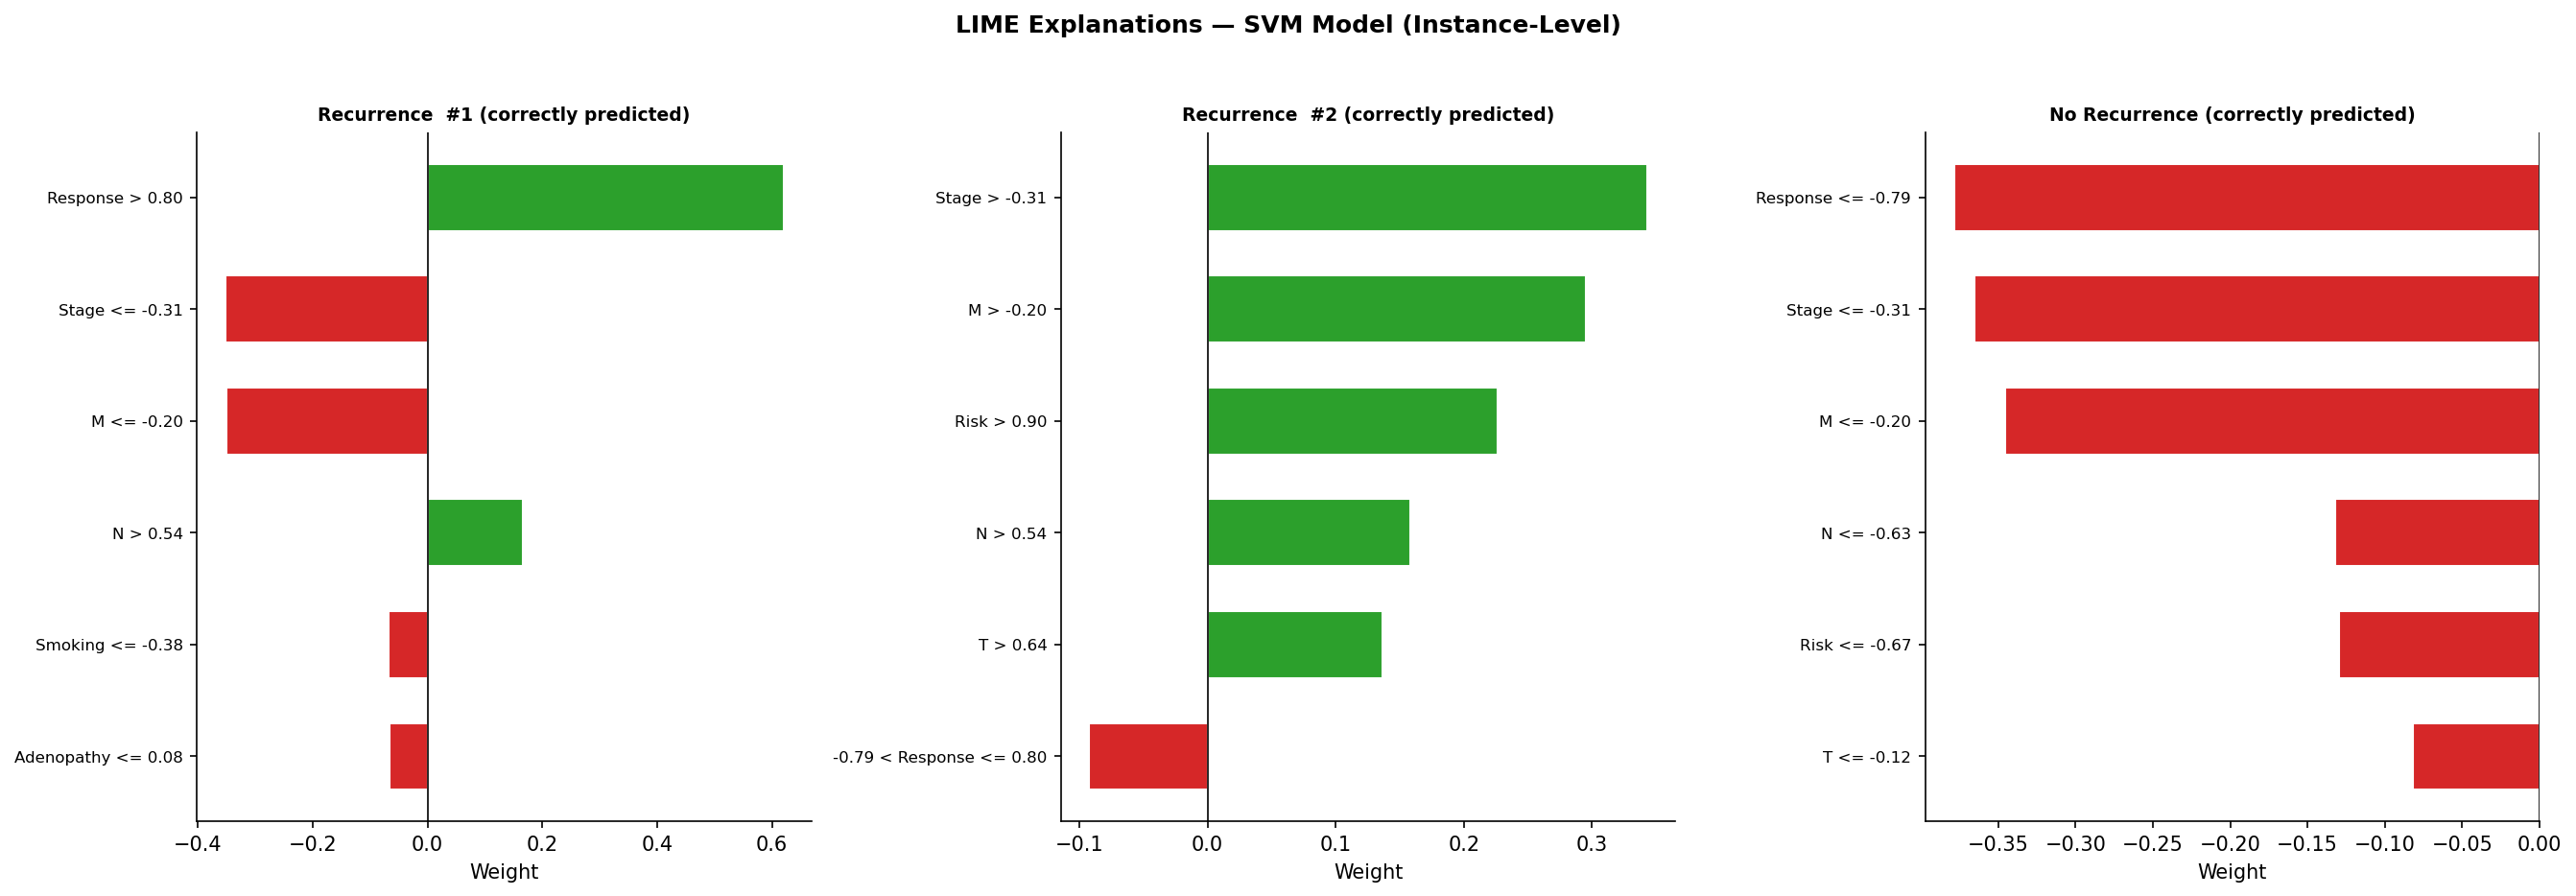

In [39]:
# ── FIG 11 — LIME Explanations (SVM, 3 instances) ─────────────
fig11, axes11 = plt.subplots(1, 3, figsize=(18, 6))
fig11.patch.set_facecolor('white')
fig11.suptitle('LIME Explanations — SVM Model (Instance-Level)',
               fontsize=12, fontweight='bold', y=1.03)

for ax_l, (label, idx) in zip(axes11, instances.items()):
    exp = lime_explainer.explain_instance(
        Ste.iloc[idx].values,
        svm_final.predict_proba,
        num_features=6,
    )
    print(label, idx)
    feats, weights = zip(*exp.as_list())
    colors = ['#2ca02c' if w > 0 else '#d62728' for w in weights]
    y_pos = range(len(feats))
    ax_l.barh(y_pos, weights, color=colors, edgecolor='white', height=0.6)
    ax_l.set_yticks(y_pos)
    ax_l.set_yticklabels(feats, fontsize=8)
    ax_l.set_xlabel('Weight', fontsize=10)
    ax_l.set_title(label.strip(), fontsize=9, fontweight='bold')
    ax_l.axvline(0, color='black', linewidth=0.8)
    ax_l.invert_yaxis()

fig11.tight_layout()
fig11.savefig(SAVE_PATH / 'Fig11_LIME_explanations.png', dpi=200, bbox_inches='tight')
print(f'Saved: LIME_explanations.png')
plt.show()

Saved: Fig_speed_benchmark.png


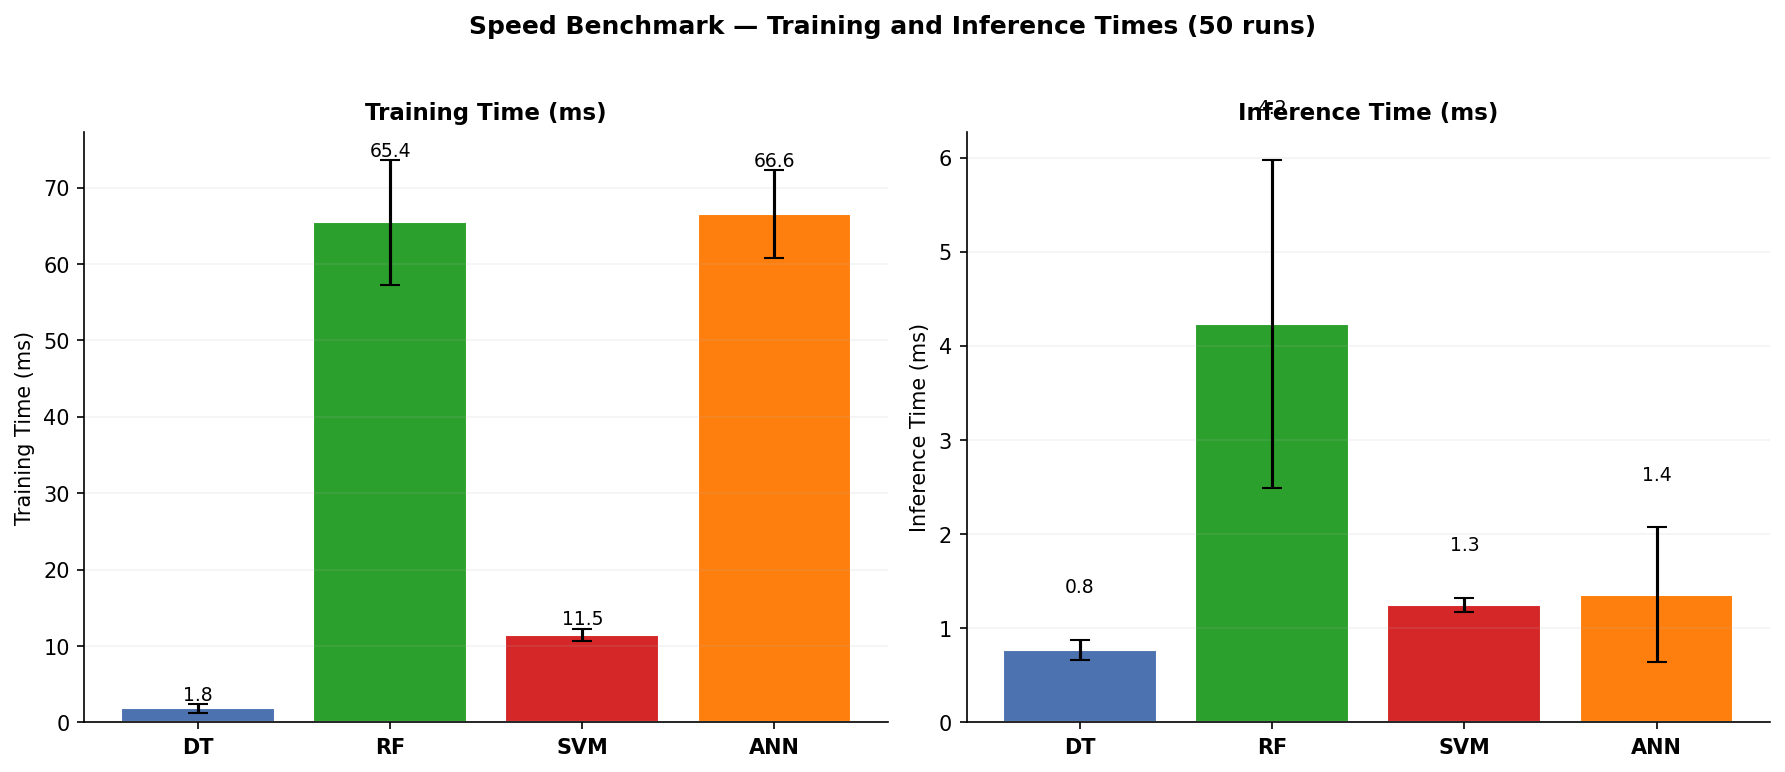

In [30]:
# ── FIG — Speed Benchmark ─────────────────────────────────────
fig_sp, axes_sp = plt.subplots(1, 2, figsize=(12, 5))
fig_sp.patch.set_facecolor('white')
fig_sp.suptitle('Speed Benchmark — Training and Inference Times (50 runs)',
                fontsize=12, fontweight='bold', y=1.02)

algo_names = list(speed_results.keys())
train_means = [speed_results[n]['train_ms'] for n in algo_names]
train_stds  = [speed_results[n]['train_std'] for n in algo_names]
infer_means = [speed_results[n]['infer_ms'] for n in algo_names]
infer_stds  = [speed_results[n]['infer_std'] for n in algo_names]

x = np.arange(len(algo_names))
for ax, means, stds, title in zip(axes_sp,
        [train_means, infer_means], [train_stds, infer_stds],
        ['Training Time (ms)', 'Inference Time (ms)']):
    bars = ax.bar(x, means, yerr=stds, capsize=5,
                  color=[COLORS[n] for n in algo_names], edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(algo_names, fontweight='bold')
    ax.set_ylabel(title, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    for b, m, s in zip(bars, means, stds):
        ax.text(b.get_x() + b.get_width()/2, m + s + 0.5,
                f'{m:.1f}', ha='center', fontsize=9)
    ax.grid(axis='y', alpha=0.15)

fig_sp.tight_layout()
fig_sp.savefig(SAVE_PATH / 'Fig_speed_benchmark.png', dpi=200, bbox_inches='tight')
print('Saved: Fig_speed_benchmark.png')
plt.show()

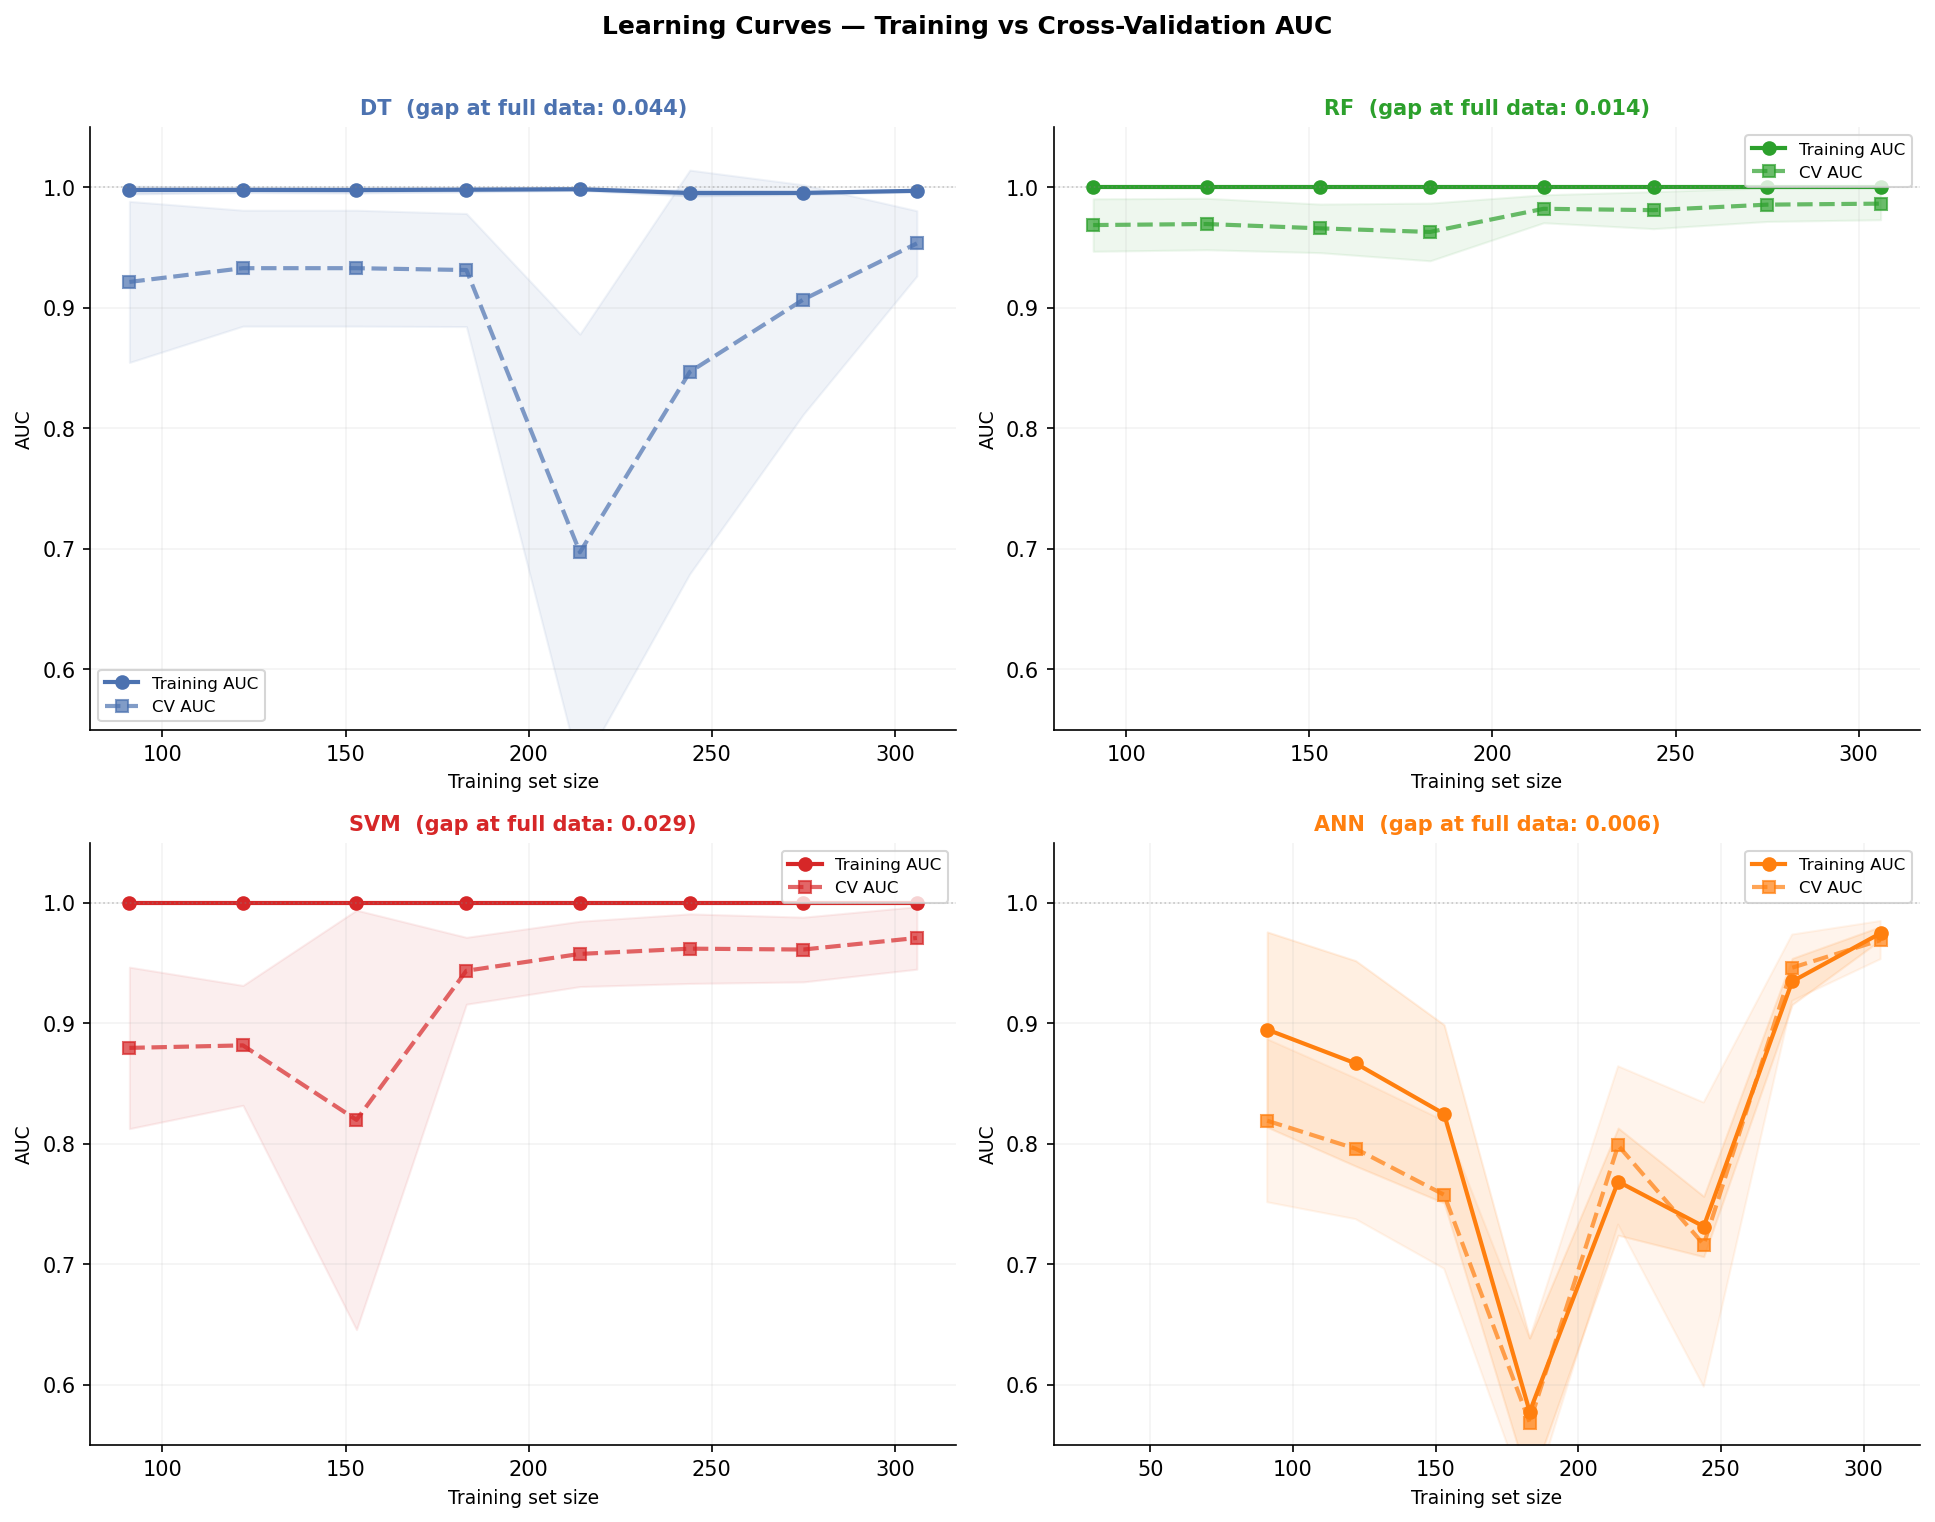

Saved: learning_curves.png


In [40]:
# FIG - Learning Curves
fig7, axes7 = plt.subplots(2, 2, figsize=(13, 10))
fig7.patch.set_facecolor('white')
fig7.suptitle('Learning Curves — Training vs Cross-Validation AUC',
              fontsize=12, fontweight='bold', y=1.01)
cv_lc       = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_sizes = np.linspace(0.10, 1.0, 10)
for ax_lc, (name, mdl) in zip(axes7.flatten(), get_tuned_models().items()):
    Xall = X_sfs_all if name in ('SVM', 'ANN') else X_fs_all
    tr_sz, tr_sc, cv_sc = learning_curve(
        mdl, Xall, y, train_sizes=train_sizes,
        cv=cv_lc, scoring='roc_auc', n_jobs=-1)
    tr_m = tr_sc.mean(axis=1); tr_s = tr_sc.std(axis=1)
    cv_m = cv_sc.mean(axis=1); cv_s = cv_sc.std(axis=1)
    ax_lc.plot(tr_sz, tr_m, 'o-', color=COLORS[name], lw=2, label='Training AUC')
    ax_lc.fill_between(tr_sz, tr_m - tr_s, tr_m + tr_s, alpha=0.12, color=COLORS[name])
    ax_lc.plot(tr_sz, cv_m, 's--', color=COLORS[name], lw=2, alpha=0.7, label='CV AUC')
    ax_lc.fill_between(tr_sz, cv_m - cv_s, cv_m + cv_s, alpha=0.08, color=COLORS[name])
    ax_lc.set_title(f'{name}  (gap at full data: {tr_m[-1]-cv_m[-1]:.3f})',
                    fontsize=10, fontweight='bold', color=COLORS[name])
    ax_lc.set_xlabel('Training set size', fontsize=9)
    ax_lc.set_ylabel('AUC', fontsize=9)
    ax_lc.legend(fontsize=8); ax_lc.set_ylim(0.55, 1.05)
    ax_lc.axhline(1.0, color='gray', lw=0.8, linestyle=':', alpha=0.4)
    ax_lc.grid(alpha=0.15)
plt.tight_layout()
plt.savefig(SAVE_PATH / 'learning_curves.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: learning_curves.png')

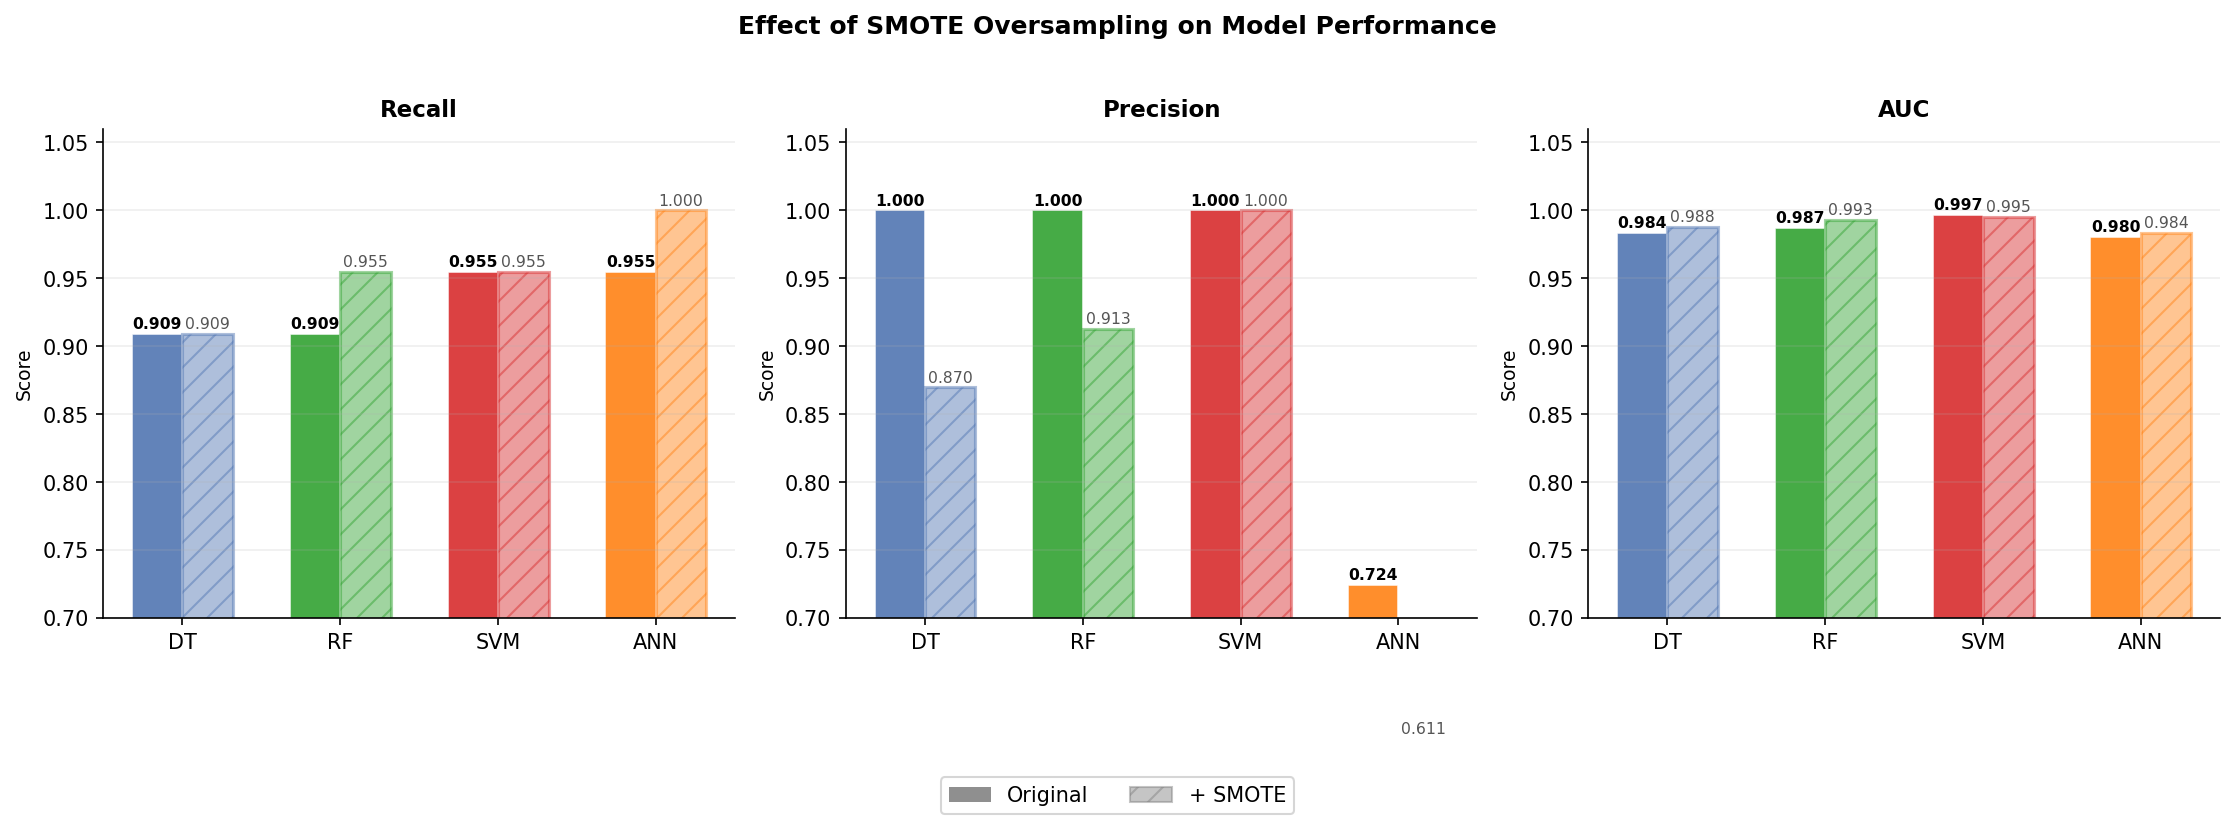

Saved: SMOTE_sensitivity.png


In [41]:
# ── FIG — SMOTE Sensitivity ─────────────────────────────────
fig8, axes8 = plt.subplots(1, 3, figsize=(15, 5))
fig8.patch.set_facecolor('white')
fig8.suptitle('Effect of SMOTE Oversampling on Model Performance',
              fontsize=12, fontweight='bold', y=1.02)
algo_names = list(COLORS.keys())
x = np.arange(len(algo_names)); w = 0.32
for ax_s, metric in zip(axes8, ['Recall', 'Precision', 'AUC']):
    orig_v  = [smote_results[n]['original'][metric] for n in algo_names]
    smote_v = [smote_results[n]['smote'][metric]    for n in algo_names]
    b1 = ax_s.bar(x - w/2, orig_v,  w, color=[COLORS[n] for n in algo_names],
                  alpha=0.88, edgecolor='white', linewidth=0.8)
    b2 = ax_s.bar(x + w/2, smote_v, w, color=[COLORS[n] for n in algo_names],
                  alpha=0.45, edgecolor=[COLORS[n] for n in algo_names],
                  linewidth=1.5, hatch='//')
    ax_s.set_title(metric, fontsize=11, fontweight='bold')
    ax_s.set_xticks(x); ax_s.set_xticklabels(algo_names, fontsize=10)
    ax_s.set_ylim(0.70, 1.06); ax_s.set_ylabel('Score', fontsize=9)
    ax_s.grid(axis='y', alpha=0.2)
    for bar, val in zip(b1, orig_v):
        ax_s.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004,
                  f'{val:.3f}', ha='center', fontsize=7.5, fontweight='bold')
    for bar, val in zip(b2, smote_v):
        ax_s.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004,
                  f'{val:.3f}', ha='center', fontsize=7.5, color='#555')
fig8.legend(handles=[Patch(facecolor='gray', alpha=0.88, label='Original'),
                     Patch(facecolor='gray', alpha=0.45, hatch='//', edgecolor='gray', label='+ SMOTE')],
            loc='lower center', ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.06))
plt.tight_layout()
plt.savefig(SAVE_PATH / 'SMOTE_sensitivity.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: SMOTE_sensitivity.png')

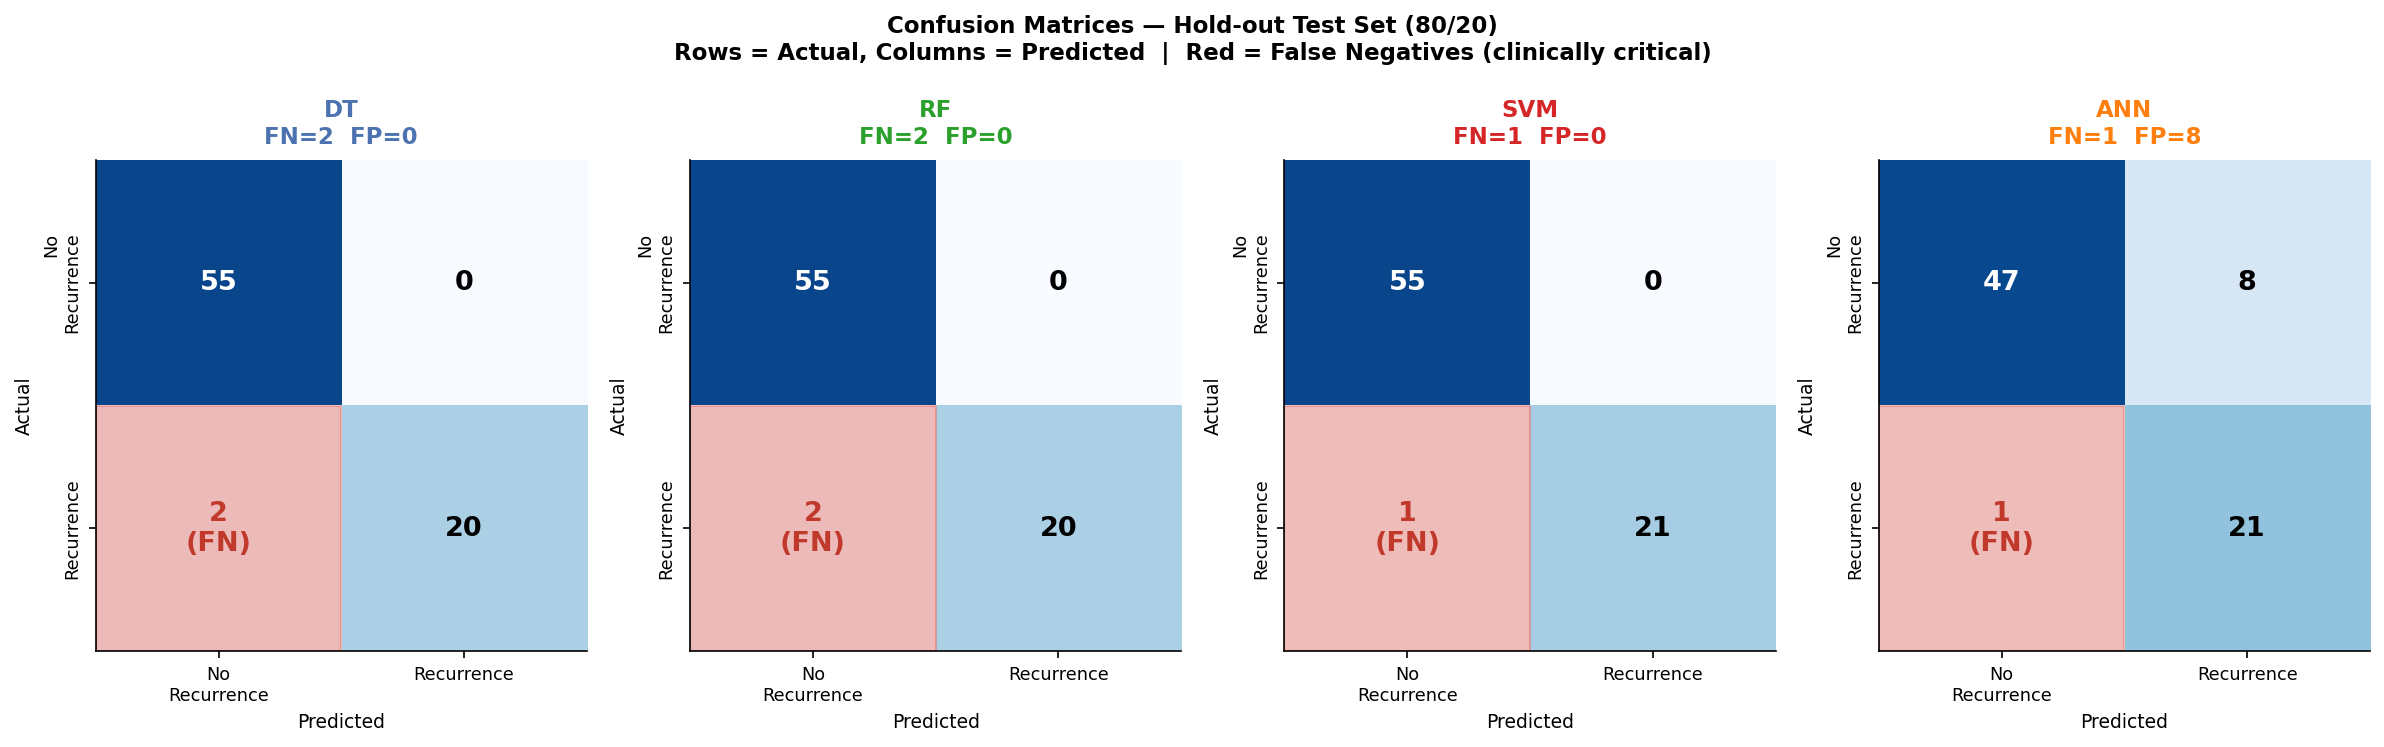

Saved: confusion_matrices.png


In [42]:
# ── FIG — Confusion Matrices ────────────────────────────────
fig9, axes9 = plt.subplots(1, 4, figsize=(16, 4.5))
fig9.patch.set_facecolor('white')
fig9.suptitle(
    'Confusion Matrices — Hold-out Test Set (80/20)\n'
    'Rows = Actual, Columns = Predicted  |  Red = False Negatives (clinically critical)',
    fontsize=11, fontweight='bold', y=1.04)
cm_labels = ['No\nRecurrence', 'Recurrence']
for ax_cm, name in zip(axes9, algo_names):
    cm = conf_matrices[name]
    ax_cm.imshow(cm, cmap='Blues', vmin=0, vmax=cm.max()+5)
    for i in range(2):
        for j in range(2):
            color = 'white' if cm[i,j] > cm.max()*0.6 else 'black'
            label = str(cm[i,j])
            if i == 1 and j == 0:   # FN cell
                ax_cm.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1,
                                fill=True, color='#E74C3C', alpha=0.35, zorder=2))
                label = f'{cm[i,j]}\n(FN)'; color = '#C0392B'
            ax_cm.text(j, i, label, ha='center', va='center',
                       fontsize=13, fontweight='bold', color=color, zorder=3)
    ax_cm.set_xticks([0, 1]); ax_cm.set_yticks([0, 1])
    ax_cm.set_xticklabels(cm_labels, fontsize=8.5)
    ax_cm.set_yticklabels(cm_labels, fontsize=8.5, rotation=90, va='center')
    ax_cm.set_xlabel('Predicted', fontsize=9); ax_cm.set_ylabel('Actual', fontsize=9)
    ax_cm.set_title(f'{name}\nFN={cm[1,0]}  FP={cm[0,1]}',
                    fontsize=11, fontweight='bold', color=COLORS[name], pad=8)
plt.tight_layout()
plt.savefig(SAVE_PATH / 'confusion_matrices.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrices.png')

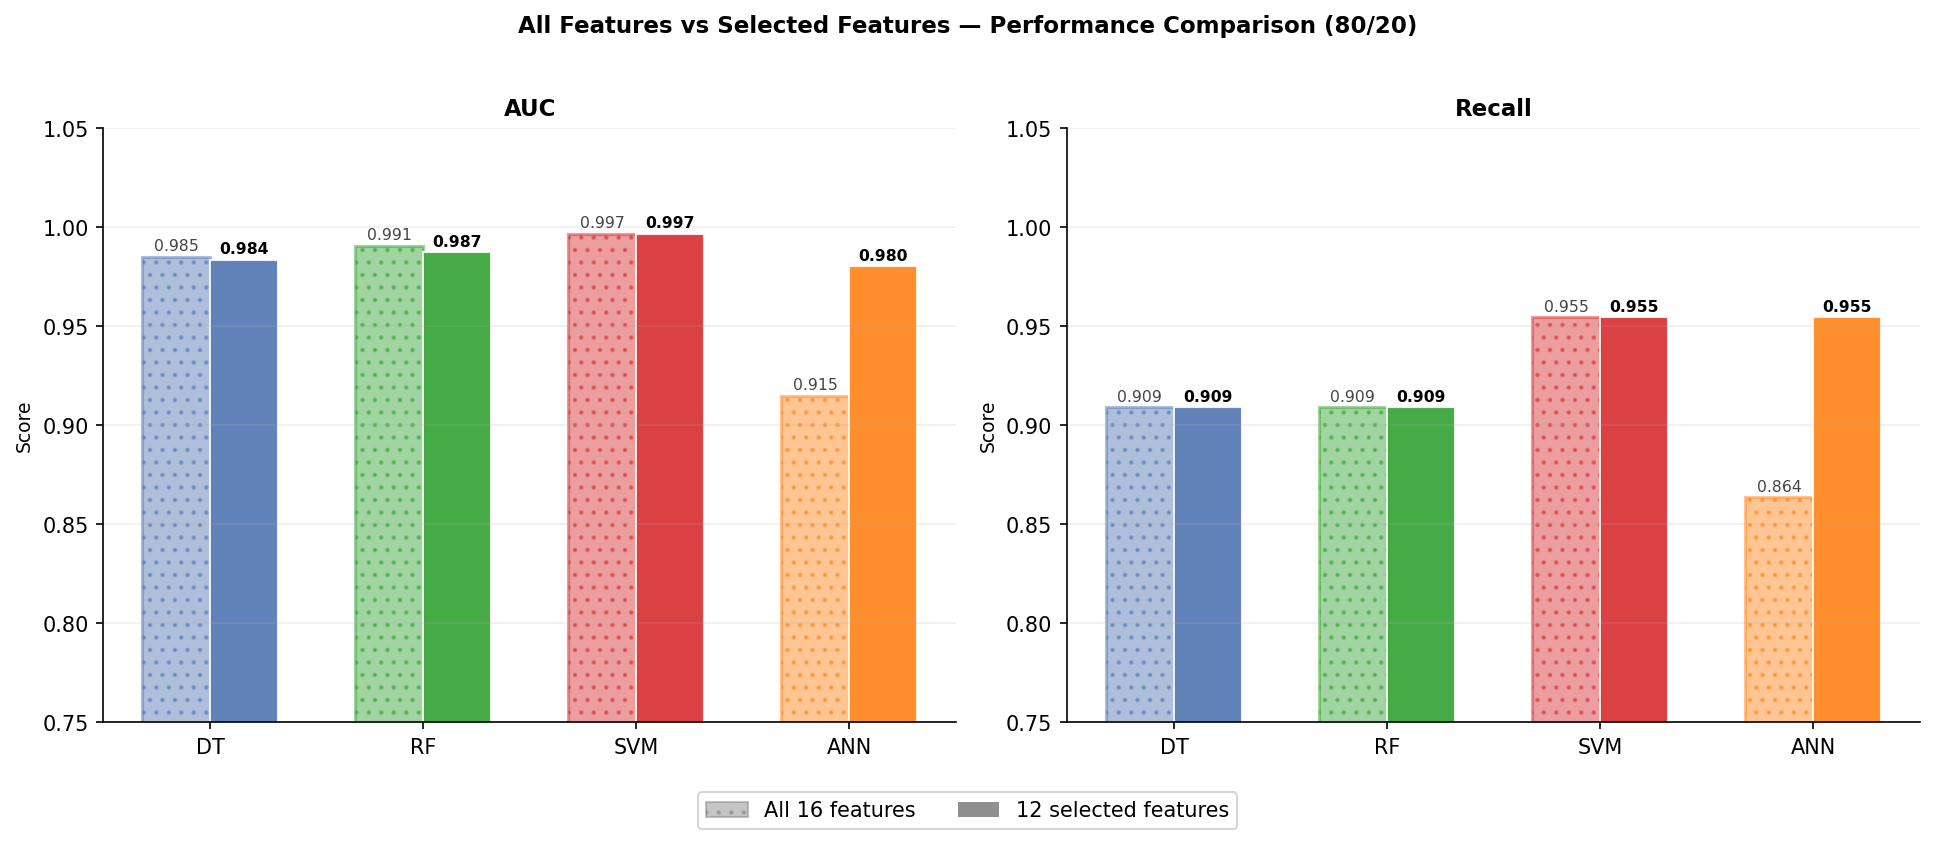

Saved: feature_selection_impact.png

All figures complete: Fig5 through Fig10


In [43]:
# ── FIG — All Features vs Selected Features comparison ─────
fig10, axes10 = plt.subplots(1, 2, figsize=(13, 5))
fig10.patch.set_facecolor('white')
fig10.suptitle('All Features vs Selected Features — Performance Comparison (80/20)',
               fontsize=11, fontweight='bold', y=1.02)

for ax_f, metric in zip(axes10, ['AUC', 'Recall']):
    x_pos = np.arange(len(algo_names)); w = 0.32
    base_vals = [baseline_results[n][metric]  for n in algo_names]
    sel_vals  = [selected_results[n][metric] for n in algo_names]
    b1 = ax_f.bar(x_pos - w/2, base_vals, w,
                  color=[COLORS[n] for n in algo_names], alpha=0.45,
                  edgecolor=[COLORS[n] for n in algo_names], linewidth=1.5,
                  hatch='..', label='All 16 features')
    b2 = ax_f.bar(x_pos + w/2, sel_vals, w,
                  color=[COLORS[n] for n in algo_names], alpha=0.88,
                  edgecolor='white', label='12 selected features')
    ax_f.set_title(metric, fontsize=11, fontweight='bold')
    ax_f.set_xticks(x_pos); ax_f.set_xticklabels(algo_names, fontsize=10)
    ax_f.set_ylim(0.75, 1.05); ax_f.set_ylabel('Score', fontsize=9)
    ax_f.grid(axis='y', alpha=0.2)
    for bar, val in zip(b1, base_vals):
        ax_f.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                  f'{val:.3f}', ha='center', fontsize=7.5, color='#444')
    for bar, val in zip(b2, sel_vals):
        ax_f.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                  f'{val:.3f}', ha='center', fontsize=7.5, fontweight='bold')

fig10.legend(handles=[Patch(facecolor='gray', alpha=0.45, hatch='..', edgecolor='gray',
                            label='All 16 features'),
                      Patch(facecolor='gray', alpha=0.88, label='12 selected features')],
             loc='lower center', ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
plt.savefig(SAVE_PATH / 'feature_selection_impact.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: feature_selection_impact.png')
print('\nAll figures complete: Fig5 through Fig10')

In [36]:
import joblib
import os

# Create output directory
os.makedirs('saved_models', exist_ok=True)

# Save the four tuned models (already fitted in Section 9)
for name, mdl in tuned_models.items():
    joblib.dump(mdl, f'saved_models/{name}_model.pkl')
    print(f'Saved: saved_models/{name}_model.pkl')

# Save the scaler (fitted on training set)
joblib.dump(scaler, 'saved_models/scaler.pkl')
print('Saved: saved_models/scaler.pkl')

# Save feature list
import json
with open('saved_models/features.json', 'w') as f:
    json.dump({'selected_features': final_features, 
               'all_features': feature_names}, f, indent=2)
print('Saved: saved_models/features.json')

# Save SHAP explainer values for reproducibility
np.save('saved_models/shap_values.npy', sv1)
print('Saved: saved_models/shap_values.npy')

print(f'\nAll artifacts saved to saved_models/')

Saved: saved_models/DT_model.pkl
Saved: saved_models/RF_model.pkl
Saved: saved_models/SVM_model.pkl
Saved: saved_models/ANN_model.pkl
Saved: saved_models/scaler.pkl
Saved: saved_models/features.json
Saved: saved_models/shap_values.npy

All artifacts saved to saved_models/
